<center>
<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/c/ca/Water_Droplet.svg/1280px-Water_Droplet.svg.png" width="400" height="200" />
</center>

# Машинное обучение для прогнозирования уровня грунтовых вод с учётом климатических факторов, типа водоносного горизонта и глубины промерзания почв


Подземные воды являются важнейшим источником пресной воды. 
Динамика уровня ГВ зависит от климатических факторов, промерзания почвы и характеристик водоносного горизонта.

**Цель:** построить ML-модель для прогноза уровня грунтовых вод и проверить переносимость модели на другой климатический регион.

**Основные цели проекта:** разработать модель машинного обучения для прогнозирования уровня грунтовых вод на основе временных рядов климатических данных и характеристик скважины. Дополнительно требуется оценить влияние отдельных факторов на динамику уровня и проверить переносимость модели на данные другой скважины.

**Источниĸи данных:**

1. *Уровни грунтовых вод:* Сourtesy of the U.S. Geological Survey (https://www.usgs.gov/). Public Domain.

2. *Климатические факторы:* Copernicus Climate Change Service, Climate Data Store, (2023): ERA5 hourly data on single levels from 1940 to present. Copernicus Climate Change Service (C3S) Climate Data Store (CDS). DOI: 10.24381/cds.adbb2d47 (Accessed on 20-FEB-2026). CC BY (Creative Commons Attribution 4.0 International).

3. *Глубины промерзания почвы:* Zhu, Guofeng; Huang, Enwei (2025), “Quantifying the Role of Winter Freezing in Global Drylands on Spring Soil Moisture”, Mendeley Data, V1, doi: 10.17632/7bctjyn98n.1. CC BY (Creative Commons Attribution 4.0 International).

> Подробное описание проекта и результаты см. в [README](../README.md)

Импорт базовых библиотек:

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import seaborn as sns

from scipy.stats import norm, spearmanr
from scipy import stats

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import statsmodels.graphics.tsaplots as sgt

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1. Анализ и обработка данных


### 1.1 Обработка и очистка данных

In [3]:
# Загружаем файл с данными о глубина до зеркала воды в скважине (Небраска)

# Пропускаем строки метаданных (все строки начинающиеся с #)
df_nb = pd.read_csv('../data/404618098504401_Nebraska.txt', 
                 sep="\t", 
                 comment="#",
                 skiprows=1)  # пропускаем первую строку 

In [4]:
df_nb.head(6)

,agency_cd,site_no,site_tp_cd,lev_dt,lev_tm,lev_tz_cd,lev_va,sl_lev_va,sl_datum_cd,lev_status_cd,lev_agency_cd,lev_dt_acy_cd,lev_acy_cd,lev_src_cd,lev_meth_cd,lev_age_cd,parameter_cd
0,5s,15s,6s,10d,5d,5s,12s,12s,10s,1s,5s,1s,1s,1s,1s,1s,5s
1,USGS,404618098504401,GW,1946-07-26,NaN,NaN,NaN,2040.15,NGVD29,1,NaN,D,2,NaN,S,A,62610
2,USGS,404618098504401,GW,1946-07-26,NaN,NaN,NaN,2041.00,NAVD88,1,NaN,D,2,NaN,S,A,62611
3,USGS,404618098504401,GW,1946-07-26,NaN,NaN,20.05,NaN,NaN,1,NaN,D,2,NaN,S,A,72019
4,USGS,404618098504401,GW,1946-08-07,NaN,NaN,NaN,2040.88,NGVD29,1,NaN,D,2,NaN,S,A,62610
5,USGS,404618098504401,GW,1946-08-07,NaN,NaN,NaN,2041.73,NAVD88,1,NaN,D,2,NaN,S,A,62611


In [5]:
# Выберем только нужные столбцы и переименуем для удобства
df_val_nb = df_nb[['site_no','lev_dt','lev_va', 'parameter_cd']]
df_val_nb = df_val_nb.rename(columns={"site_no": "site_no", "lev_va": "depth_feet", "lev_dt": "date", "parameter_cd": "parameter_cd"})
df_val_nb.head(6)

,site_no,date,depth_feet,parameter_cd
0,15s,10d,12s,5s
1,404618098504401,1946-07-26,NaN,62610
2,404618098504401,1946-07-26,NaN,62611
3,404618098504401,1946-07-26,20.05,72019
4,404618098504401,1946-08-07,NaN,62610
5,404618098504401,1946-08-07,NaN,62611


In [6]:
df_val_nb.shape

(10993, 4)

In [7]:
# Удаляем первую строку, которая содержит заголовок
df_val_nb.drop(index=[0], inplace=True)

In [8]:
# Проверим, что все значения пренадлежат одной скважине
df_val_nb['site_no'].unique()

array(['404618098504401'], dtype=object)

In [9]:
# Выберим только те значения параметра системы координат, которые соответсвуют глубине воды ниже поверхности земли
df_val_nb = df_val_nb[df_val_nb['parameter_cd'] == '72019']
df_val_nb.head(3)

,site_no,date,depth_feet,parameter_cd
3,404618098504401,1946-07-26,20.05,72019
6,404618098504401,1946-08-07,19.32,72019
9,404618098504401,1946-09-05,19.79,72019


In [10]:
# Преобразуем дату и глубину
df_val_nb['date'] = pd.to_datetime(df_val_nb['date'])
df_val_nb['year'] = df_val_nb['date'].dt.year
df_val_nb['month'] = df_val_nb['date'].dt.month
df_val_nb['depth_feet'] = df_val_nb['depth_feet'].astype(float)
df_val_nb.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3664 entries, 3 to 10992
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   site_no       3664 non-null   object        
 1   date          3664 non-null   datetime64[ns]
 2   depth_feet    3664 non-null   float64       
 3   parameter_cd  3664 non-null   object        
 4   year          3664 non-null   int32         
 5   month         3664 non-null   int32         
dtypes: datetime64[ns](1), float64(1), int32(2), object(2)
memory usage: 171.8+ KB


Проверим нерерывны ли наблюдения внутри временного ряда данных. При наличие пропусков в данных, если это возможно приведем ряд к непрерывному виду. 

In [11]:
# Определим года с <= 6 месяцами данных
year_counts = df_val_nb.groupby('year')['month'].nunique()
valid_years = year_counts[year_counts > 6].index
no_valid_years = year_counts[year_counts <= 6].index
print('Года с <= 6 месяцев данных за год:', list(no_valid_years))

Года с <= 6 месяцев данных за год: [1946, 2000, 2002, 2003, 2004, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]


In [12]:
# Оставляем годы с > 6 месяцами данных
df_clean = df_val_nb[df_val_nb['year'].isin(valid_years)].copy()

In [13]:
# Проинтерполируем данные где это возможно
interpolated = []
removed_years = []

for year in df_clean['year'].unique():
    year_data = df_clean[df_clean['year'] == year].drop_duplicates(subset=['month'])
    missing_months = set(range(1, 13)) - set(year_data['month'])
    
    if len(missing_months) == 0:
        continue
    
    # Полный ряд 12 месяцев
    full_year = pd.DataFrame({'month': range(1, 13)})
    full_year = full_year.merge(year_data[['month', 'depth_feet']], on='month', how='left')
    full_year['depth_feet'] = full_year['depth_feet'].interpolate(method='linear', limit_area='inside')
    
    # Проверяем
    if full_year['depth_feet'].isna().any():
        removed_years.append(year)
    else:
        # Сохраняем интерполированные
        for m in missing_months:
            row = full_year[full_year['month'] == m].iloc[0]
            interpolated.append({
                'site_no': year_data['site_no'].iloc[0],
                'date': pd.to_datetime(f"{year}-{m}-01"),
                'depth_feet': row['depth_feet'],
                'parameter_cd': year_data['parameter_cd'].iloc[0],
                'year': year,
                'month': m,
                'interpolated': True
            })

df_val_nb_clean = df_clean[~df_clean['year'].isin(removed_years)]
interpolated_df = pd.DataFrame(interpolated)

print(f"Интерполировано: {len(interpolated_df)} записей")
print(f"Удалено годов: {len(removed_years)}")
if removed_years:
    print(f"Удалённые годы: {removed_years}")

Интерполировано: 5 записей
Удалено годов: 2
Удалённые годы: [np.int32(1956), np.int32(2011)]


In [14]:
interpolated_df.head(3)

,site_no,date,depth_feet,parameter_cd,year,month,interpolated
0,404618098504401,1950-02-01,16.980,72019,1950,2,True
1,404618098504401,1950-04-01,16.750,72019,1950,4,True
2,404618098504401,2001-02-01,18.985,72019,2001,2,True


In [15]:
# Объединяем с основной таблицей
df_val_nb_final = pd.concat([
    df_val_nb_clean.assign(interpolated=False),
    interpolated_df
]).sort_values(['year', 'month']).reset_index(drop=True)

df_val_nb_final.head(3)

,site_no,date,depth_feet,parameter_cd,year,month,interpolated
0,404618098504401,1947-01-05,18.43,72019,1947,1,False
1,404618098504401,1947-01-10,18.38,72019,1947,1,False
2,404618098504401,1947-01-15,18.38,72019,1947,1,False


In [16]:
df_val_nb_final.shape

(3518, 7)

In [17]:
# Посмотрим есть ли пропущенные годы после интерполяции внутри полученного временного ряда
missing_years = set(range(df_val_nb_final['year'].min(), df_val_nb_final['year'].max() + 1)) - set(df_val_nb_final['year'].unique())

print('Год начала данных:', df_val_nb_final['year'].min())
print('Год окончания данных:', df_val_nb_final['year'].max())
print('Пропущенные годы:', sorted(missing_years))


Год начала данных: 1947
Год окончания данных: 2010
Пропущенные годы: [1956, 2000, 2002, 2003, 2004]


In [18]:
# Для получения непрерывного временного ряда данных удалим данные за 1947-1955 и 2001-2010 годы
df_val_nb_final = df_val_nb_final[
    ~((df_val_nb_final['year'] >= 1947) & (df_val_nb_final['year'] <= 1955)) &
    ~((df_val_nb_final['year'] >= 2001) & (df_val_nb_final['year'] <= 2010))
]
df_val_nb_final.head(3)

,site_no,date,depth_feet,parameter_cd,year,month,interpolated
620,404618098504401,1957-01-31,26.02,72019,1957,1,False
621,404618098504401,1957-02-05,26.01,72019,1957,2,False
622,404618098504401,1957-02-10,26.00,72019,1957,2,False


In [19]:
# Убедимся что теперь во временном ряду отсутствуют пропуски
missing_years = set(range(df_val_nb_final['year'].min(), df_val_nb_final['year'].max() + 1)) - set(df_val_nb_final['year'].unique())
missing_years

set()

In [20]:
# Проверяем на нули
df_val_nb_final['depth_feet'].eq(0).sum()

np.int64(0)

In [21]:
df_val_nb_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2794 entries, 620 to 3413
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   site_no       2794 non-null   object        
 1   date          2794 non-null   datetime64[ns]
 2   depth_feet    2794 non-null   float64       
 3   parameter_cd  2794 non-null   object        
 4   year          2794 non-null   int32         
 5   month         2794 non-null   int64         
 6   interpolated  2794 non-null   bool          
dtypes: bool(1), datetime64[ns](1), float64(1), int32(1), int64(1), object(2)
memory usage: 144.6+ KB


In [22]:
# Переводим глубину из футов в метры
df_val_nb_final['depth_m'] = df_val_nb_final['depth_feet'] * 0.3048

In [23]:
df_val_nb_final['depth_m'].describe()

count    2794.000000
mean        7.100955
std         0.749083
min         3.569208
25%         6.623304
50%         7.114032
75%         7.629144
max         8.906256
Name: depth_m, dtype: float64

In [24]:
# Создаём месячную агрегированную таблицу (средняя глубина по месяцам)
monthly_nb = df_val_nb_final.groupby(['site_no', 'year', 'month'])['depth_m'].mean().reset_index()
monthly_nb.head(3)

,site_no,year,month,depth_m
0,404618098504401,1957,1,7.930896
1,404618098504401,1957,2,7.918704
2,404618098504401,1957,3,7.901940


Cоздадим дополнительный признак - месячное изменение уровня грунтовых вод ``Δdepth_m = depth_m(t) - depth_m(t-1)``. В дальнейшем данный временной ряд будет использован при анализе данных и прогнозировании уровня грунтовых вод.

In [25]:
# Добавляем cтолбец с delta_depth_m
monthly_nb['delta_depth_m'] = monthly_nb['depth_m'].diff()

In [26]:
# Добавляем cтолбец с датой первого числа месяца
monthly_nb['month_start'] = pd.to_datetime(monthly_nb[['year', 'month']].assign(day=1))
monthly_nb.head(3)

,site_no,year,month,depth_m,delta_depth_m,month_start
0,404618098504401,1957,1,7.930896,NaN,1957-01-01
1,404618098504401,1957,2,7.918704,-0.012192,1957-02-01
2,404618098504401,1957,3,7.901940,-0.016764,1957-03-01


In [27]:
monthly_nb.dtypes

site_no                  object
year                      int32
month                     int64
depth_m                 float64
delta_depth_m           float64
month_start      datetime64[ns]
dtype: object

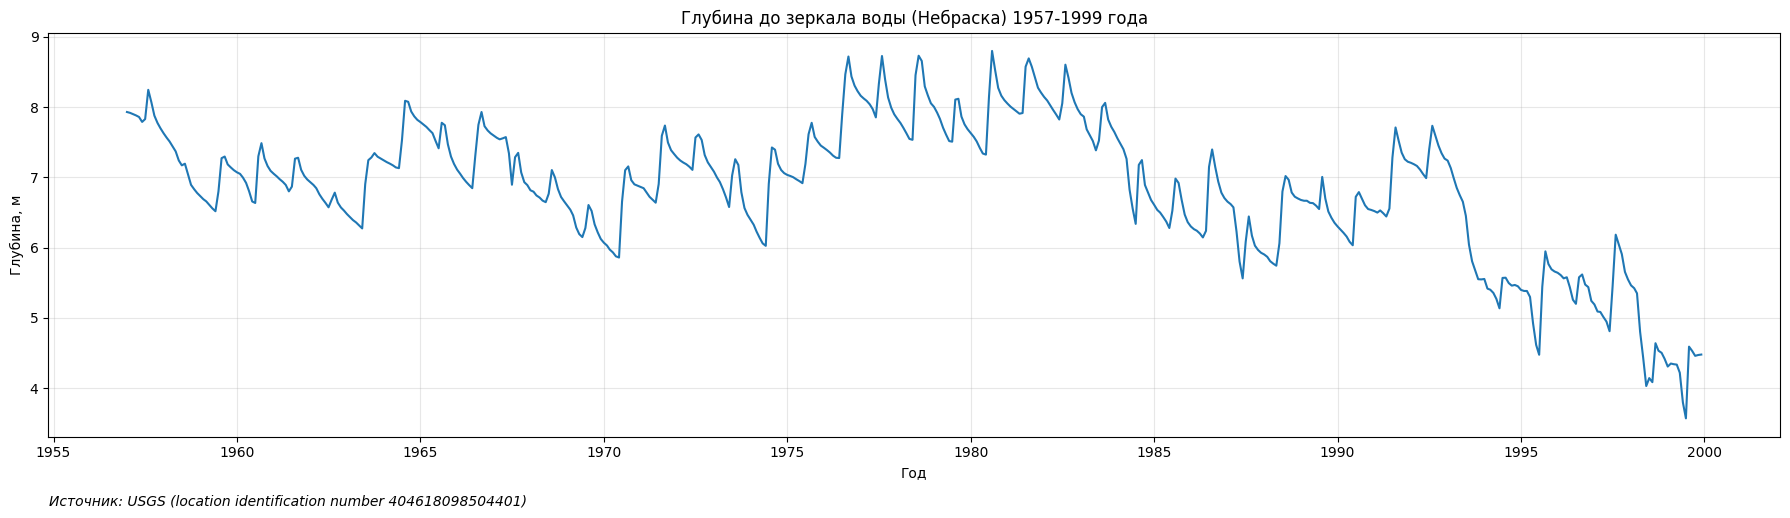

In [28]:
# График
fig, ax = plt.subplots(figsize=(18, 5))
ax.plot(monthly_nb['month_start'], monthly_nb['depth_m'])
ax.set_title("Глубина до зеркала воды (Небраска) 1957-1999 года")
ax.set_xlabel("Год")
ax.set_ylabel("Глубина, м")
ax.grid(True, alpha=0.3)

# Добавляем подпись источника
fig.text(0.03, -0.02, 'Источник: USGS (location identification number 404618098504401)', 
         ha='left', fontsize=10, style='italic')
fig.tight_layout()
plt.savefig('../visualizations/groundwater_level_nebraska.png', dpi=150, bbox_inches='tight')
plt.show()


In [29]:
print('Год начала данных:', monthly_nb['year'].min())
print('Год окончания данных:', monthly_nb['year'].max())
print('Глубина до зеркала воды min:', round(monthly_nb['depth_m'].min(), 2))
print('Глубина до зеркала воды max:', round(monthly_nb['depth_m'].max(), 2))
print('Глубина до зеркала воды mean:', round(monthly_nb['depth_m'].mean(), 2))

Год начала данных: 1957
Год окончания данных: 1999
Глубина до зеркала воды min: 3.57
Глубина до зеркала воды max: 8.8
Глубина до зеркала воды mean: 6.86


Итоговая выборка данных по скважине в штате Небраска охватывают период наблюдений с 1957 по 1999 год - это 43 года непрерывных наблюдений. Это достаточно длительный ряд данных об уровне грунтовых вод, что делает его идеальным для анализа и построения прогностических моделей.

Глубина до зеркала воды варьируется от 3.57 до 8.80 метров относительно поверхности земли, при среднем значении 6.86 метров. Такой широкий диапазон (более 5 метров) свидетельствует о значительной сезонной и многолетней изменчивости уровня грунтовых вод. 

In [30]:
# Загружаем файл с данными о температуре воздуха и осадках в районе скважины (Небраска)
# Источник: ERA5 data (Copernicus Climate Change Service, 2023)
# Загружаем ERA5 данные
ds_temp_nb = xr.open_dataset("../data/era5_temp_combined_Nebraska.nc")
ds_precip_nb = xr.open_dataset("../data/era5_precip_combined_Nebraska.nc")

In [31]:
# Для каждой даты valid_time выбираем первое не-NaN значение
def extract_monthly_values(ds, var_name):
    """Извлекает месячные значения из сложной структуры ERA5"""
    values = []
    dates = []
    
    for vt in ds.valid_time.values:
        # Выбираем данные для этой valid_time
        subset = ds[var_name].sel(valid_time=vt)
        
        # Находим первое не-NaN значение
        non_nan = subset.where(~np.isnan(subset), drop=True)
        
        if len(non_nan) > 0:
            # Усредняем по lat/lon и берем значение
            val = non_nan.mean(dim=['latitude', 'longitude']).values
            # Берем скалярное значение
            values.append(val.item() if hasattr(val, 'item') else float(val))
            dates.append(vt)
        else:
            print(f"Нет данных для {vt}")
    
    return np.array(values), np.array(dates)

# Извлекаем значения
temp_values_nb, temp_dates_nb = extract_monthly_values(ds_temp_nb, 't2m')
precip_values_nb, precip_dates_nb = extract_monthly_values(ds_precip_nb, 'tp')
print("Температура (месяцев):", len(temp_values_nb))
print("Осадки (месяцев):", len(precip_values_nb)) 

Температура (месяцев): 960
Осадки (месяцев): 960


In [32]:
# Создаем DataFrame с данными о температуре (Небраска) 
# Переведем температуру из градусов Кельвинов в Цельсия
df_temp_nb = pd.DataFrame({
    'temp_dates': pd.to_datetime(temp_dates_nb).normalize(),
    'temp_C': temp_values_nb - 273.15   # K -> °C
})
df_temp_nb.head()

,temp_dates,temp_C
0,1946-01-01,-2.342139
1,1946-02-01,0.712823
2,1946-03-01,7.609460
3,1946-04-01,13.187494
4,1946-05-01,13.345392


In [33]:
# Создаем DataFrame с данными об осадках (Небраска) 
# Переведем осадки из м в мм
df_precip_nb = pd.DataFrame({
    'precip_dates': pd.to_datetime(precip_dates_nb).normalize(),
    'precip_mm': precip_values_nb * 1000 # м -> мм
})
df_precip_nb.head()

,precip_dates,precip_mm
0,1946-01-01,0.415590
1,1946-02-01,0.277837
2,1946-03-01,3.648758
3,1946-04-01,1.001358
4,1946-05-01,3.700256


In [34]:
# Проверим, есть ли все даты precip в temp
all_in_dt_wht = df_temp_nb['temp_dates'].isin(df_precip_nb['precip_dates']).all()
print("Все даты temp_dates есть в precip_dates:", all_in_dt_wht)

Все даты temp_dates есть в precip_dates: True


In [35]:
# Создаём единый датасет погоды
df_weather_nb = df_temp_nb[['temp_dates', 'temp_C']].merge(
    df_precip_nb[['precip_dates', 'precip_mm']], 
    left_on='temp_dates', 
    right_on='precip_dates',
    how='inner'
)
# Удаляем дублирующийся столбец даты и переименовываем
df_weather_nb = df_weather_nb.drop(columns=['precip_dates']).rename(columns={'temp_dates': 'date'})
df_weather_nb.head(3)

,date,temp_C,precip_mm
0,1946-01-01,-2.342139,0.415590
1,1946-02-01,0.712823,0.277837
2,1946-03-01,7.609460,3.648758


In [36]:
df_weather_nb.shape

(960, 3)

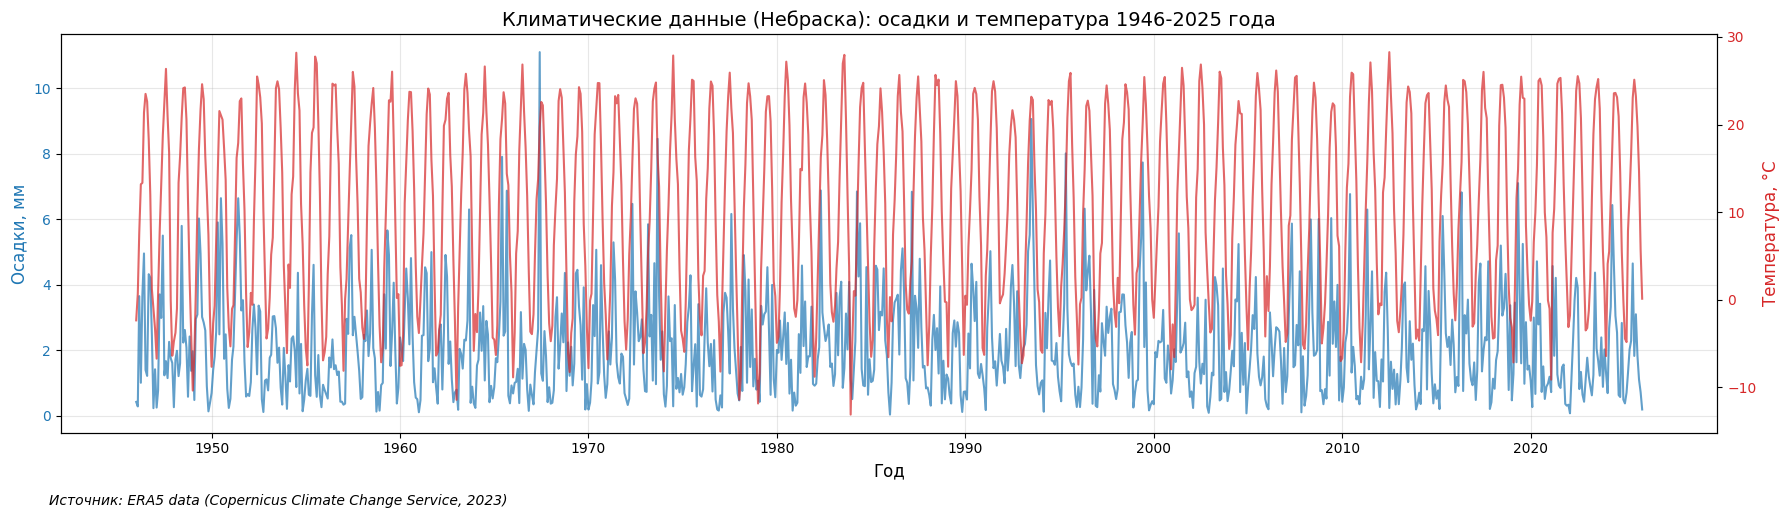

In [37]:
# Визуализируем климатические данные (Небраска)
fig, ax1 = plt.subplots(figsize=(18, 5))

# Осадки на левой оси
color1 = 'tab:blue'
ax1.set_xlabel('Год', fontsize=12)
ax1.set_ylabel('Осадки, мм', color=color1, fontsize=12)
ax1.plot(df_weather_nb['date'], df_weather_nb['precip_mm'], color=color1, alpha=0.7, label='Осадки, мм')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.grid(True, alpha=0.3)

# Температура на правой оси
ax2 = ax1.twinx()
color2 = 'tab:red'
ax2.set_ylabel('Температура, °C', color=color2, fontsize=12)
ax2.plot(df_weather_nb['date'], df_weather_nb['temp_C'], color=color2, alpha=0.7, label='Температура, °C')
ax2.tick_params(axis='y', labelcolor=color2)

plt.title('Климатические данные (Небраска): осадки и температура 1946-2025 года', fontsize=14)
fig.tight_layout()

# Добавляем подпись источника
fig.text(0.03, -0.02, 'Источник: ERA5 data (Copernicus Climate Change Service, 2023)', 
         ha='left', fontsize=10, style='italic')
plt.savefig('../visualizations/climate_data_nebraska.png', dpi=150, bbox_inches='tight')
plt.show()

In [38]:
print('Год начала данных:', df_weather_nb['date'].min())
print('Год окончания данных:', df_weather_nb['date'].max())
print('Всего записей:', len(df_weather_nb['date']))
print()
print('Температура (°C):')
print('min:', round(df_weather_nb["temp_C"].min(), 2))
print('max:', round(df_weather_nb["temp_C"].max(), 2))
print('mean:', round(df_weather_nb["temp_C"].mean(), 2))
print()
print('Осадки (mm):')
print('min:', round(df_weather_nb["precip_mm"].min(), 2))
print('max:', round(df_weather_nb["precip_mm"].max(), 2))
print('mean:', round(df_weather_nb["precip_mm"].mean(), 2))


Год начала данных: 1946-01-01 00:00:00
Год окончания данных: 2025-12-01 00:00:00
Всего записей: 960

Температура (°C):
min: -13.09
max: 28.26
mean: 10.43

Осадки (mm):
min: 0.03
max: 11.11
mean: 2.09


Температура воздуха варьируется от -13.09 °C (зимний минимум) до 28.26 °C (летний максимум), при среднегодовом значении 10.43 °C. Это типично для континентального климата с резкими сезонными колебаниями.
Среднемесячные осадки составляют в среднем 2.09 мм, с диапазоном от 0.03 до 11.11 мм. Относительно низкое среднее значение осадков характерно для засушливых регионов Великих Равнин.

Всего 960 записей (месяцев). Данные об уровне грунтовых вод, температуре и осадках согласованы по временной шкале.

In [39]:
# Загружаем данные о глубине сезонного промерзания в скважине (Небраска)
freeze_df_nb = pd.read_csv("../data/404618098504401_well_freeze_df.csv")

# Заменим значения -9999 (nodata) на NaN
freeze_df_nb['freeze_depth'] = freeze_df_nb['freeze_depth'].replace(-9999.0, np.nan)
print(freeze_df_nb.head(3))

         date  freeze_depth
0  1950-01-01      0.922771
1  1950-02-01      0.686363
2  1950-03-01      0.480471


In [40]:
# Преобразуем дату
freeze_df_nb['date'] = pd.to_datetime(freeze_df_nb['date'])

In [41]:
freeze_df_nb.dtypes

date            datetime64[ns]
freeze_depth           float64
dtype: object

In [42]:
freeze_df_nb['freeze_depth'].describe()

count    898.000000
mean       0.145834
std        0.295421
min        0.000000
25%        0.000000
50%        0.000000
75%        0.006592
max        1.306107
Name: freeze_depth, dtype: float64

In [43]:
freeze_df_nb.shape

(898, 2)

In [44]:
freeze_df_nb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 898 entries, 0 to 897
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          898 non-null    datetime64[ns]
 1   freeze_depth  898 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 14.2 KB


Значения глубины промерзания получены расчетным путем, поэтому в данных присутсвуют значения в интервале 0.0 - 0.01 м. В реальных (полевых) измерениях глубины промерзания точность обычно составляет 1 см. Заменим на 0.0 м значения глубины промерзания меньше 0.01 м. 

In [45]:
# Проверяем значения глубины промерзания > 0 и <= 0.01 м 
small_freeze = freeze_df_nb[(freeze_df_nb['freeze_depth'] > 0) & (freeze_df_nb['freeze_depth'] <= 0.01)]
print("Значений > 0 и <= 0.01 м:", len(small_freeze))

Значений > 0 и <= 0.01 м: 245


In [46]:
# Заменяем на 0
freeze_df_nb.loc[(freeze_df_nb['freeze_depth'] > 0) & (freeze_df_nb['freeze_depth'] <= 0.01), 'freeze_depth'] = 0
print("Значений > 0 и <= 0.01 м:", ((freeze_df_nb['freeze_depth'] > 0) & (freeze_df_nb['freeze_depth'] <= 0.01)).sum())

Значений > 0 и <= 0.01 м: 0


In [47]:
# Округлим значения глубины промерзания до 2 знаков после запятой
freeze_df_nb['freeze_depth'] = freeze_df_nb['freeze_depth'].round(2)

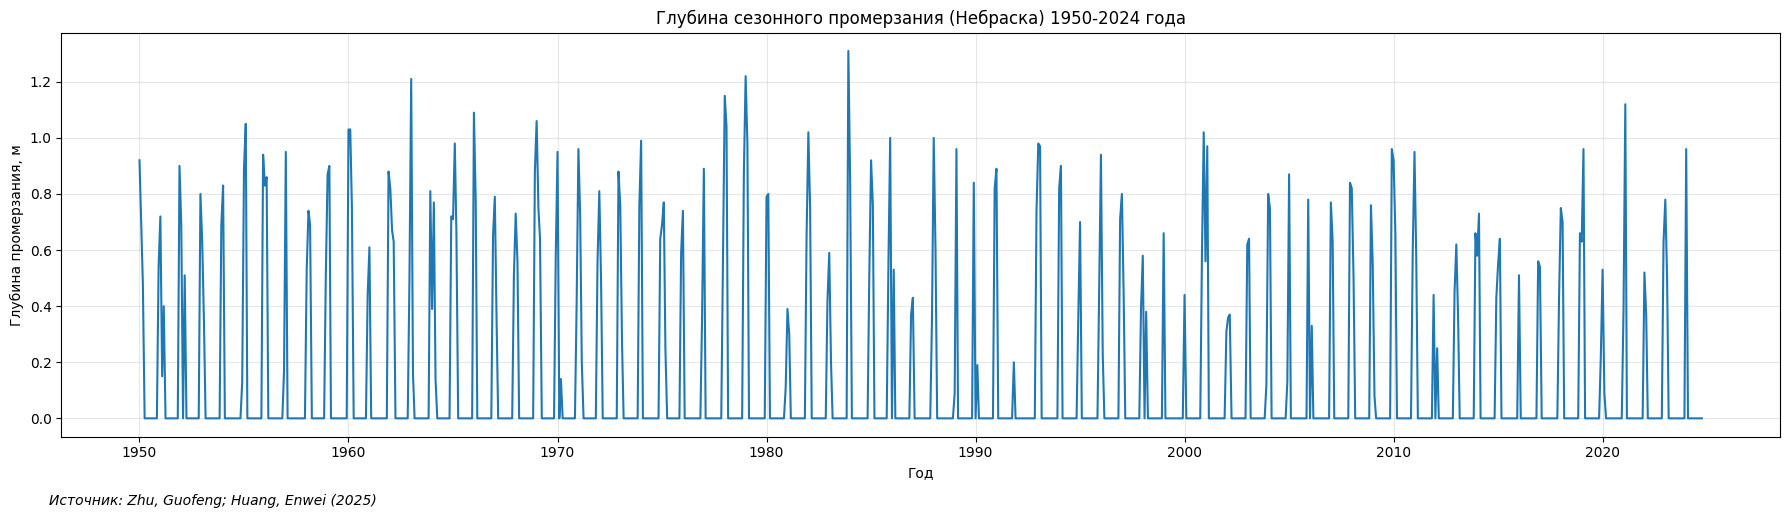

In [48]:
# Визуализируем данные о глубины сезонного промерзания (Небраска) 
fig, ax = plt.subplots(figsize=(18, 5))
ax.plot(freeze_df_nb['date'], freeze_df_nb["freeze_depth"])
ax.set_title("Глубина сезонного промерзания (Небраска) 1950-2024 года")
ax.set_xlabel("Год")
ax.set_ylabel("Глубина промерзания, м")
ax.grid(True, alpha=0.3)
fig.tight_layout()

# Добавляем подпись источника
fig.text(0.03, -0.02, 'Источник: Zhu, Guofeng; Huang, Enwei (2025)', 
         ha='left', fontsize=10, style='italic')
plt.savefig('../visualizations/freeze_depth_nebraska.png', dpi=150, bbox_inches='tight')
plt.show()

In [49]:
print('Год начала данных:', freeze_df_nb['date'].min())
print('Год окончания данных:', freeze_df_nb['date'].max())
print('Всего записей:', len(freeze_df_nb['date']))
print()
print('Глубина промерзания (м):')
print('min:', round(freeze_df_nb["freeze_depth"].min(), 2))
print('max:', round(freeze_df_nb["freeze_depth"].max(), 2))
print('mean:', round(freeze_df_nb["freeze_depth"].mean(), 2))

Год начала данных: 1950-01-01 00:00:00
Год окончания данных: 2024-10-01 00:00:00
Всего записей: 898

Глубина промерзания (м):
min: 0.0
max: 1.31
mean: 0.14


Данные о глубина промерзания охватывают период с 1950 по 2024 год (75 лет). Максимальная глубина промерзания достигает 1.31 м, что характерно для континентального климата. Среднее значение 0.14 м указывает на умеренное сезонное промерзание. Нулевые значения соответствуют периодам без промерзания (весна-лето-осень).

Всего 898 записей (месяцев). Данные о глубине промерзания не согласованы по временной шкале с данными о грунтовых вод, температуре и осадках. Начало данных - 1950 год.

In [50]:
# Объединяем monthly_nb + df_weather_nb + freeze_df_nb
# Используем monthly_nb как основу

# Подготовка данных для объединения
df_weather_nb_merged = df_weather_nb.rename(columns={'date': 'month_start'})
freeze_df_merged = freeze_df_nb.rename(columns={'date': 'month_start'})

# Объединяем: monthly_nb_filtered + weather + freeze
nb_data = monthly_nb.merge(df_weather_nb_merged, on='month_start', how='left')
nb_data = nb_data.merge(freeze_df_merged, on='month_start', how='left')
nb_data.head()

,site_no,year,month,depth_m,delta_depth_m,month_start,temp_C,precip_mm,freeze_depth
0,404618098504401,1957,1,7.930896,NaN,1957-01-01,-8.095496,0.331031,0.95
1,404618098504401,1957,2,7.918704,-0.012192,1957-02-01,0.082910,0.364621,0.00
2,404618098504401,1957,3,7.901940,-0.016764,1957-03-01,2.376733,2.955543,0.00
3,404618098504401,1957,4,7.882636,-0.019304,1957-04-01,8.759821,2.496719,0.00
4,404618098504401,1957,5,7.860030,-0.022606,1957-05-01,14.655206,5.130768,0.00


In [51]:
nb_data.shape

(516, 9)

In [52]:
# Проверим еще раз нет ли годов с количеством месяцев != 12
year_counts = nb_data.groupby('year').size().reset_index(name='months_count')
incomplete_years = year_counts[year_counts['months_count'] != 12]
print(f"Годов с < 12 месяцами: {len(incomplete_years)}")
if len(incomplete_years) > 0:
    print("Годы с неполными данными:")
    print(incomplete_years)
else:
    print("Все годы содержат 12 месяцев данных")

Годов с < 12 месяцами: 0
Все годы содержат 12 месяцев данных


In [53]:
nb_data.reset_index(drop=True, inplace=True)

In [54]:
nb_data.head(3)

,site_no,year,month,depth_m,delta_depth_m,month_start,temp_C,precip_mm,freeze_depth
0,404618098504401,1957,1,7.930896,NaN,1957-01-01,-8.095496,0.331031,0.95
1,404618098504401,1957,2,7.918704,-0.012192,1957-02-01,0.082910,0.364621,0.00
2,404618098504401,1957,3,7.901940,-0.016764,1957-03-01,2.376733,2.955543,0.00


In [55]:
nb_data[['depth_m', 'temp_C', 'precip_mm', 'freeze_depth']].describe()

,depth_m,temp_C,precip_mm,freeze_depth
count,516.000000,516.000000,516.000000,516.000000
mean,6.856111,10.111123,2.174086,0.151899
std,0.965254,10.567445,1.625623,0.309988
min,3.569208,-13.094946,0.028398,0.000000
25%,6.386921,0.474992,0.907792,0.000000
50%,6.971828,11.022836,1.825333,0.000000
75%,7.530973,19.974191,3.106647,0.000000
max,8.800447,27.952386,11.106491,1.310000


In [56]:
print('Год начала данных:', nb_data['year'].min())
print('Год окончания данных:', nb_data['year'].max())
print('Всего записей:', len(nb_data['year']))
print('Пропущенные годы:', sorted(set(range(nb_data['year'].min(), nb_data['year'].max() + 1)) - set(nb_data['year'].unique())))

Год начала данных: 1957
Год окончания данных: 1999
Всего записей: 516
Пропущенные годы: []


Визуализируем таблицу, сгруппировав и усреднив данные по месяцам за весь рассматриваемый период с 1950 по 2010 года.

In [57]:
# Считаем среднемесячные значения
df_final_nb_means= nb_data.groupby('month').agg({
    'depth_m': 'mean',
    'temp_C': 'mean',
    'precip_mm': 'mean',
    'freeze_depth': 'mean'
}).reset_index()
df_final_nb_means.round(2)

,month,depth_m,temp_C,precip_mm,freeze_depth
0,1,6.87,-5.41,0.77,0.75
1,2,6.82,-2.25,1.04,0.46
2,3,6.78,3.03,2.09,0.10
3,4,6.70,10.16,2.72,0.00
4,5,6.61,16.30,3.75,0.00
5,6,6.52,21.67,3.69,0.00
6,7,6.82,24.48,2.65,0.00
7,8,7.22,23.32,2.65,0.00
8,9,7.19,18.17,2.72,0.00
9,10,7.00,11.61,1.81,0.00


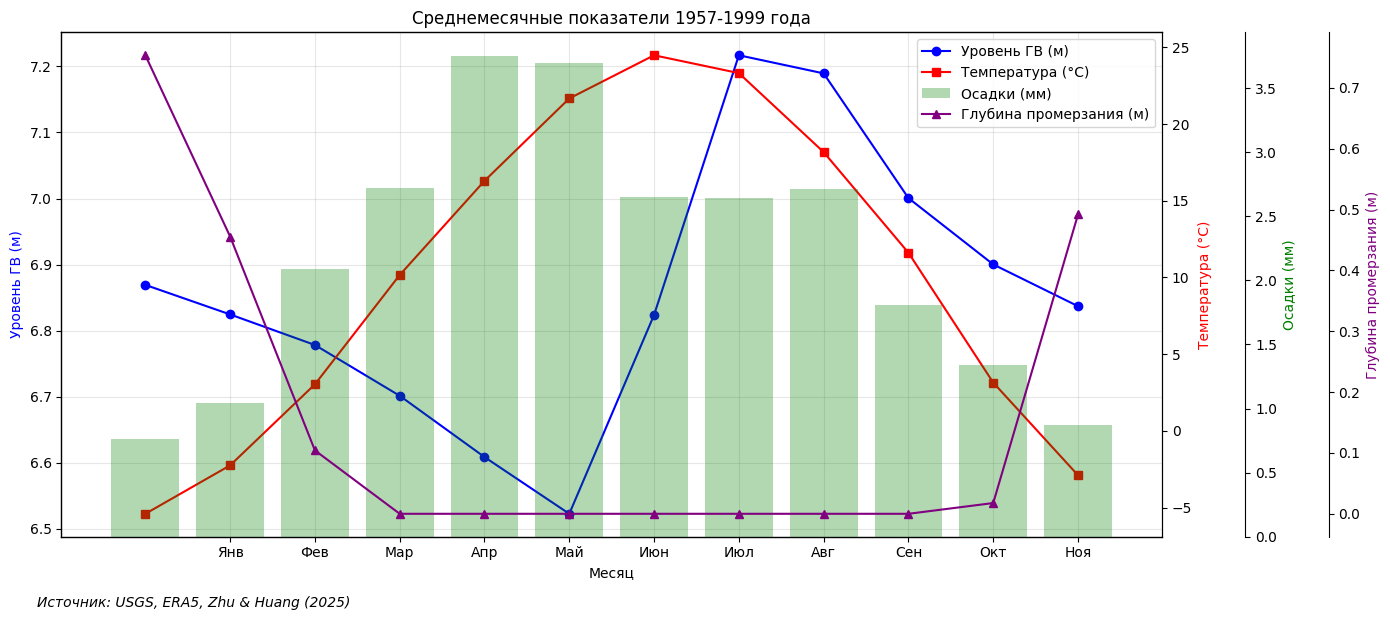

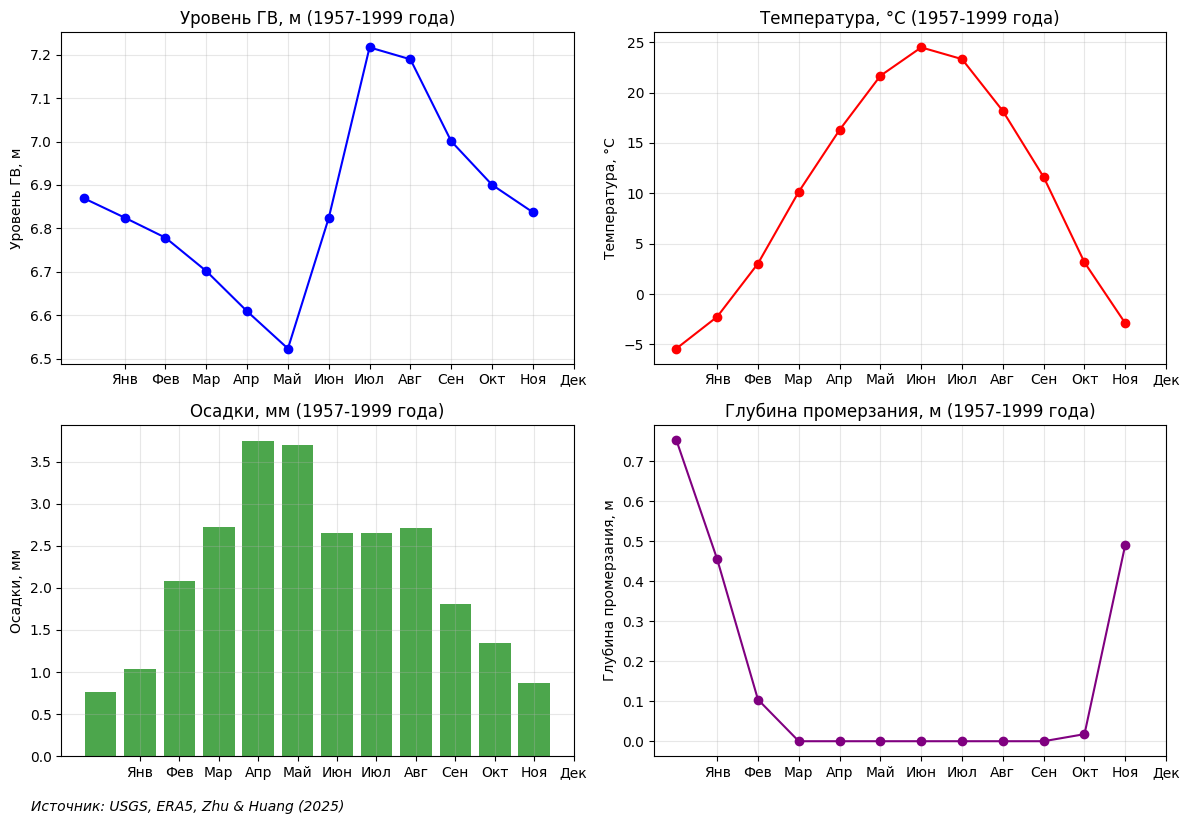

In [58]:
# Средние по месяцам
numeric_cols = ['depth_m', 'temp_C', 'precip_mm', 'freeze_depth']
months = ['Янв', 'Фев', 'Мар', 'Апр', 'Май', 'Июн', 'Июл', 'Авг', 'Сен', 'Окт', 'Ноя', 'Дек']

# Все показатели на одном графике
fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.plot(df_final_nb_means.index, df_final_nb_means['depth_m'], 'o-', color='blue', label='Уровень ГВ (м)')
ax1.set_xlabel('Месяц')
ax1.set_ylabel('Уровень ГВ (м)', color='blue')
ax1.set_xticks(range(1, 13))
ax1.set_xticklabels(months)

ax2 = ax1.twinx()
ax2.plot(df_final_nb_means.index, df_final_nb_means['temp_C'], 's-', color='red', label='Температура (°C)')
ax2.set_ylabel('Температура (°C)', color='red')

ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 60))
ax3.bar(df_final_nb_means.index, df_final_nb_means['precip_mm'], alpha=0.3, color='green', label='Осадки (мм)')
ax3.set_ylabel('Осадки (мм)', color='green')

ax4 = ax1.twinx()
ax4.spines['right'].set_position(('outward', 120))
ax4.plot(df_final_nb_means.index, df_final_nb_means['freeze_depth'], '^-', color='purple', label='Глубина промерзания (м)')
ax4.set_ylabel('Глубина промерзания (м)', color='purple')

# Объединяем легенды
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
lines3, labels3 = ax3.get_legend_handles_labels()
lines4, labels4 = ax4.get_legend_handles_labels()
ax1.legend(lines1 + lines2 + lines3 + lines4, labels1 + labels2 + labels3 + labels4, loc='upper right')

ax1.grid(True, alpha=0.3)
plt.title('Среднемесячные показатели 1957-1999 года')
fig.text(0.03, -0.02, 'Источник: USGS, ERA5, Zhu & Huang (2025)', ha='left', fontsize=10, style='italic')
plt.tight_layout()
plt.show()

# Отдельные графики
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
colors = ['blue', 'red', 'green', 'purple']
units = {'depth_m': 'м', 'temp_C': '°C', 'precip_mm': 'мм', 'freeze_depth': 'м'}
labels = {'depth_m': 'Уровень ГВ', 'temp_C': 'Температура', 
          'precip_mm': 'Осадки', 'freeze_depth': 'Глубина промерзания'}

for i, (col, color) in enumerate(zip(numeric_cols, colors)):
    ax = axes[i//2, i%2]
    if col in ['precip_mm']:
        ax.bar(df_final_nb_means.index, df_final_nb_means[col], color=color, alpha=0.7)
    else:
        ax.plot(df_final_nb_means.index, df_final_nb_means[col], 'o-', color=color)
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(months)
    ax.set_title(f"{labels[col]}, {units[col]} (1957-1999 года)")
    ax.set_ylabel(f"{labels[col]}, {units[col]}")
    ax.grid(True, alpha=0.3)
fig.text(0.03, -0.02, 'Источник: USGS, ERA5, Zhu & Huang (2025)', ha='left', fontsize=10, style='italic')
plt.tight_layout()
plt.show()

Итоговый датасет по скважине Nebraska охватывают период с 1957 по 1999 год. Рассматриваема выборка из 43 лет наблюдений не содержат пропусков. Данные очищены, агрегированы по месяцам, переменные имеют физический смысл и могут использоваться как признаки для прогнозирования уровня грунтовых вод.

В среднемесячных значениях данных можно отметить следующие закономерности: 

- Уровень грунтовых вод демонстрирует выраженную сезонность: минимальная глубина (максимальный уровень) наблюдается в весенние месяцы (апрель-май), максимальная глубина — в конце лета и осенью;
- Температура воздуха имеет типичный годовой ход с минимумом в январе-феврале (-5...-7°C) и максимумом в июле-августе (24-26°C);
- Осадки распределены неравномерно в течение года с максимумом в летние месяцы (июнь-июль);
- Глубина промерзания достигает максимума в зимние месяцы (декабрь-февраль, до 0.7-0.9 м) и отсутствует в теплый период.

Добавим признаки соответствующие геологической характеристики скважины. 

Для этого:

- Выбираем признаки скважины с сайта `USGS` (https://waterdata.usgs.gov/monitoring-location/USGS-404618098504401/#dataTypeId=continuous-72019-0&period=P7D&showMedian=true&showFieldMeasurements=true).

- Преобразуем признаки для модели используя `National Aquifer Code Reference List`(https://www.usgs.gov/mission-areas/water-resources/science/national-aquifer-code-reference-list#overview).

- Сформируем таблицу признаков, отражающих геологические характеристики, которые могут влиять на уровень грунтовых вод.



In [59]:
# Метаданные скважины
well_data = {
'site_id': ['404618098504401'],
'national_aquifer_cd': ['N100HGHPLN'], # National aquifer code
'national_aquifer_name': ['High Plains aquifer'], # National aquifer name
'local_aquifer_cd': ['112SDGVD'], # Local aquifer code
'local_aquifer_name': ['Sand and Gravel Deposits'], # Local aquifer name
'aquifer_type': ['U'], # U = Unconfined, C = Confined
'well_depth_ft': [38] # Глубина скважины в футах
}

df_well = pd.DataFrame(well_data)

In [60]:
# Расшифровка National aquifer
rock_map = {100: 'Sand and gravel', 300: 'Sandstone', 400: 'Carbonate', 600: 'Igneous/metamorphic'}
df_well['rock_code'] = df_well['national_aquifer_cd'].str[1:4].astype(int)
df_well['rock_type'] = df_well['rock_code'].map(rock_map)

# Расшифровка типа горизонта
type_map = {'U': 'Unconfined', 'C': 'Confined'}
df_well['aquifer_type_name'] = df_well['aquifer_type'].map(type_map)

# Перевод глубины в метры
df_well['well_depth_m'] = df_well['well_depth_ft'] * 0.3048

display(df_well)

,site_id,national_aquifer_cd,national_aquifer_name,local_aquifer_cd,local_aquifer_name,aquifer_type,well_depth_ft,rock_code,rock_type,aquifer_type_name,well_depth_m
0,404618098504401,N100HGHPLN,High Plains aquifer,112SDGVD,Sand and Gravel Deposits,U,38,100,Sand and gravel,Unconfined,11.5824


### 1.2 Статистический анализ данных

In [61]:
# Описательная статистика для всех переменных
numeric_cols = ['depth_m', 'temp_C', 'precip_mm', 'freeze_depth']
stats_df = nb_data[numeric_cols].describe().T
stats_df['median'] = nb_data[numeric_cols].median()
stats_df['std'] = nb_data[numeric_cols].std()
stats_df['skew'] = nb_data[numeric_cols].skew()
stats_df['kurtosis'] = nb_data[numeric_cols].kurtosis()
stats_df.round(2)

,count,mean,std,min,25%,50%,75%,max,median,skew,kurtosis
depth_m,516.0,6.86,0.97,3.57,6.39,6.97,7.53,8.80,6.97,-0.73,0.48
temp_C,516.0,10.11,10.57,-13.09,0.47,11.02,19.97,27.95,11.02,-0.14,-1.28
precip_mm,516.0,2.17,1.63,0.03,0.91,1.83,3.11,11.11,1.83,1.35,2.80
freeze_depth,516.0,0.15,0.31,0.00,0.00,0.00,0.00,1.31,0.00,1.83,1.93


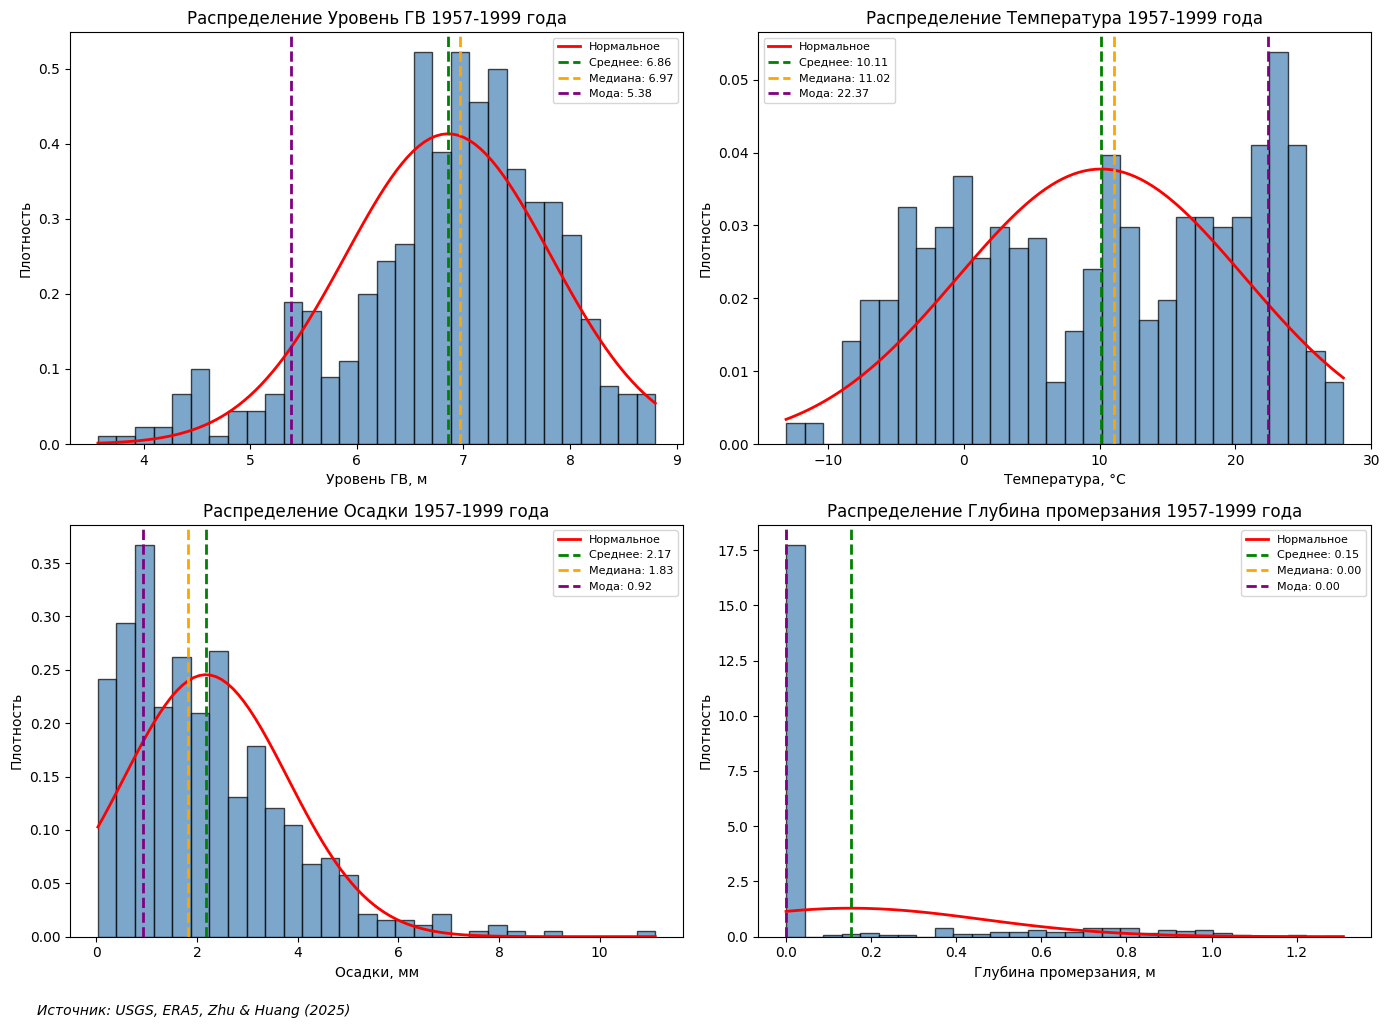

In [62]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
units = {'depth_m': 'м', 'temp_C': '°C', 'precip_mm': 'мм', 'freeze_depth': 'м'}
labels = {'depth_m': 'Уровень ГВ', 'temp_C': 'Температура', 
          'precip_mm': 'Осадки', 'freeze_depth': 'Глубина промерзания'}

for i, col in enumerate(numeric_cols):
    ax = axes[i//2, i%2]
    data = nb_data[col].dropna()
    
    # Гистограмма
    n, bins, patches = ax.hist(data, bins=30, density=True, alpha=0.7, 
                                color='steelblue', edgecolor='black')
    
    # Статистики
    mean_val = data.mean()
    median_val = data.median()
    mode_val = data.mode().iloc[0] if len(data.mode()) > 0 else mean_val
    
    # Кривая нормального распределения
    x = np.linspace(data.min(), data.max(), 100)
    ax.plot(x, norm.pdf(x, mean_val, data.std()), 'r-', linewidth=2, label='Нормальное')
    
    # Линии статистик
    ax.axvline(mean_val, color='green', linestyle='--', linewidth=2, label=f'Среднее: {mean_val:.2f}')
    ax.axvline(median_val, color='orange', linestyle='--', linewidth=2, label=f'Медиана: {median_val:.2f}')
    ax.axvline(mode_val, color='purple', linestyle='--', linewidth=2, label=f'Мода: {mode_val:.2f}')
    
    ax.set_title(f'Распределение {labels[col]} 1957-1999 года')
    ax.set_xlabel(f'{labels[col]}, {units[col]}')
    ax.set_ylabel('Плотность')
    ax.legend(fontsize=8)

fig.tight_layout()
fig.text(0.03, -0.02, 'Источник: USGS, ERA5, Zhu & Huang (2025)', ha='left', fontsize=10, style='italic')
plt.savefig('../visualizations/distribution_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

По гистограммам можно сделать следующие выводы:

- Уровень ГВ демонстрирует стабильность и близость к нормальному распределению. Значения группируются вокруг центрального значения (около 7 м), редкие отклонения не искажают общую картину.
- Температура распределена ассиметрично. Присутствуют экстремальные значения (жара), которые смещают распределение. Большинство значений сосредоточено в умеренном диапазоне, но есть редкие, но сильные отклонения.
- Осадки распределена ассиметрично. Преобладают малые осадки, крупные значения — редкость. Распределение несимметрично, с высокой концентрацией в нижней части диапазона.
- Глубина промерзания распределена крайне асимметрично. В большинстве случаев промерзания нет или оно минимально. Значительные глубины промерзания — исключительные случаи, что искажает нормальное распределение.

### 1.3 Анализ выбросов

Визуализируем выбросы с помощью boxplot диаграммы. 

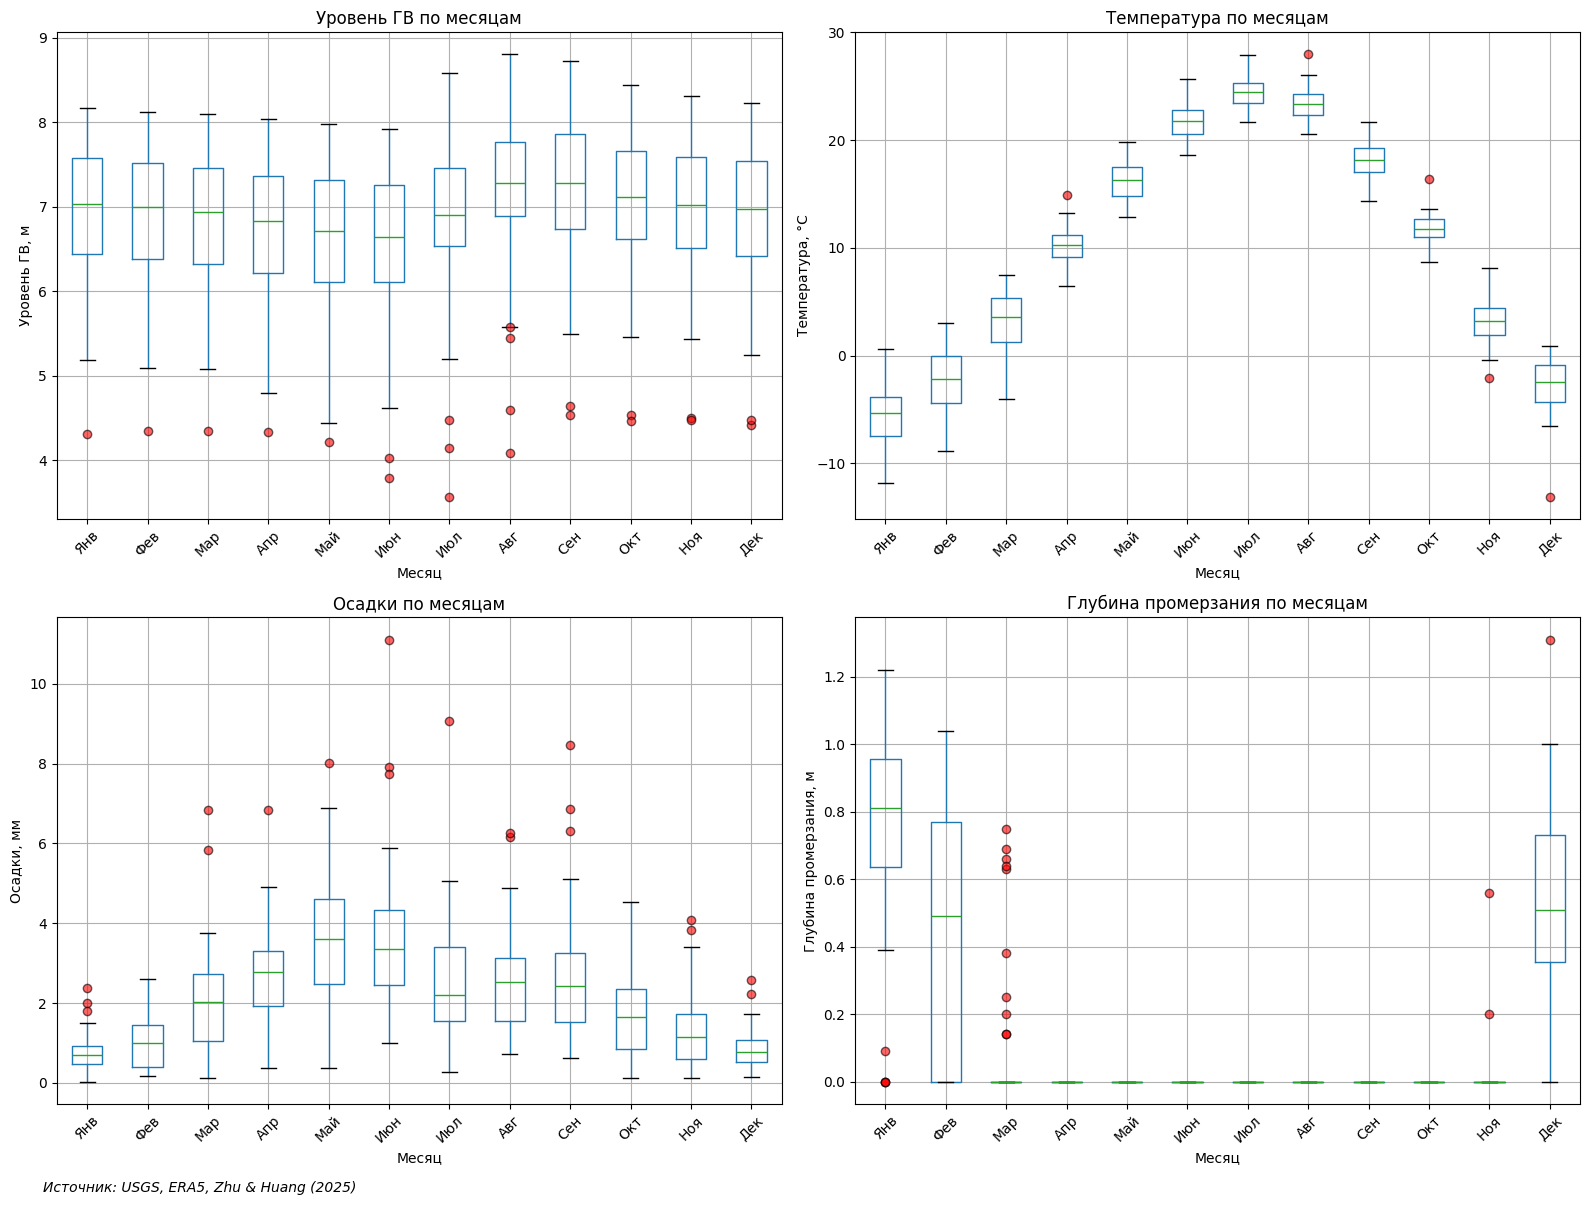

In [63]:
# Boxplot по месяцам 
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
units = {'depth_m': 'м', 'delta_depth_m': 'м', 'temp_C': '°C', 'precip_mm': 'мм', 'freeze_depth': 'м'}
labels = {'depth_m': 'Уровень ГВ', 'delta_depth_m': 'Изменение уровень ГВ', 'temp_C': 'Температура', 
          'precip_mm': 'Осадки', 'freeze_depth': 'Глубина промерзания'}

for i, col in enumerate(numeric_cols):
    ax = axes[i//2, i%2]
    
    # Boxplot по месяцам
    bp = nb_data.boxplot(column=col, by='month', ax=ax, return_type='dict')
    
    # Выделяем выбросы красным
    for flier in bp[col]['fliers']:
        flier.set(marker='o', markerfacecolor='red', markersize=6, alpha=0.6)
    
    ax.set_title(f'{labels[col]} по месяцам')
    ax.set_xlabel('Месяц')
    ax.set_ylabel(f'{labels[col]}, {units[col]}')
    ax.set_xticklabels(months, rotation=45)

plt.suptitle('')
fig.tight_layout()
fig.text(0.03, -0.01, 'Источник: USGS, ERA5, Zhu & Huang (2025)', ha='left', fontsize=10, style='italic')
plt.savefig('../visualizations/boxplot_by_month.png', dpi=150, bbox_inches='tight')
plt.show()

По характеру распределения выбросов для признаков на box-plot диаграммах можно предположить, что они являются истинными (естественными) и отражают реальную вариативность природных процессов, а не ошибки измерения или ввода данных. 

Для систематизации полученных данных и более детального анализа составим таблицу, которая позволит структурировать информацию о выбросах по каждому признаку. 

In [64]:
def get_monthly_outliers_iqr(df, column, min_value=None):
    """Находит выбросы для каждого месяца отдельно"""
    all_outliers = []
    
    for month in range(1, 13):
        data = df[df['month'] == month][column]
        if len(data) == 0:
            continue
        
        Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
        IQR = Q3 - Q1
        lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
        
        if min_value is not None:
            lower = max(lower, min_value)
        
        mask = (data < lower) | (data > upper)
        outliers = df[(df['month'] == month) & mask].copy()
        
        if len(outliers) > 0:
            outliers['lower_bound'] = lower
            outliers['upper_bound'] = upper
            all_outliers.append(outliers)
    
    return pd.concat(all_outliers) if all_outliers else pd.DataFrame()

# Создаем общую таблицу выбросов
all_outliers_combined = pd.DataFrame()

for col in numeric_cols:
    min_val = 0 if col in ['precip_mm', 'freeze_depth'] else None
    outliers = get_monthly_outliers_iqr(nb_data, col, min_val)
    
    if len(outliers) > 0:
        outliers['parameter'] = col
        outliers['value'] = outliers[col]
        outliers['datetime'] = pd.to_datetime(outliers[['year', 'month']].assign(day=1))
        all_outliers_combined = pd.concat([all_outliers_combined, outliers])

all_outliers_combined = all_outliers_combined[['parameter', 'year', 'month', 'value', 'lower_bound', 'upper_bound', 'datetime']]
all_outliers_combined = all_outliers_combined.sort_values(['parameter', 'year', 'month']).reset_index(drop=True)
all_outliers_combined.head(10)

,parameter,year,month,value,lower_bound,upper_bound,datetime
0,depth_m,1994,8,5.571744,5.572633,9.076817,1994-08-01
1,depth_m,1995,7,4.474464,5.151719,8.847201,1995-07-01
2,depth_m,1995,8,5.443728,5.572633,9.076817,1995-08-01
3,depth_m,1998,6,4.029456,4.379858,8.985023,1998-06-01
4,depth_m,1998,7,4.142232,5.151719,8.847201,1998-07-01
5,depth_m,1998,8,4.084320,5.572633,9.076817,1998-08-01
6,depth_m,1998,9,4.639056,5.070203,9.524347,1998-09-01
7,depth_m,1998,10,4.532376,5.076535,9.197866,1998-10-01
8,depth_m,1998,11,4.501896,4.892503,9.205495,1998-11-01
9,depth_m,1998,12,4.416552,4.727217,9.227146,1998-12-01


Посмотрим как распределены выбросы в данных в пределах временного интервала выборки.

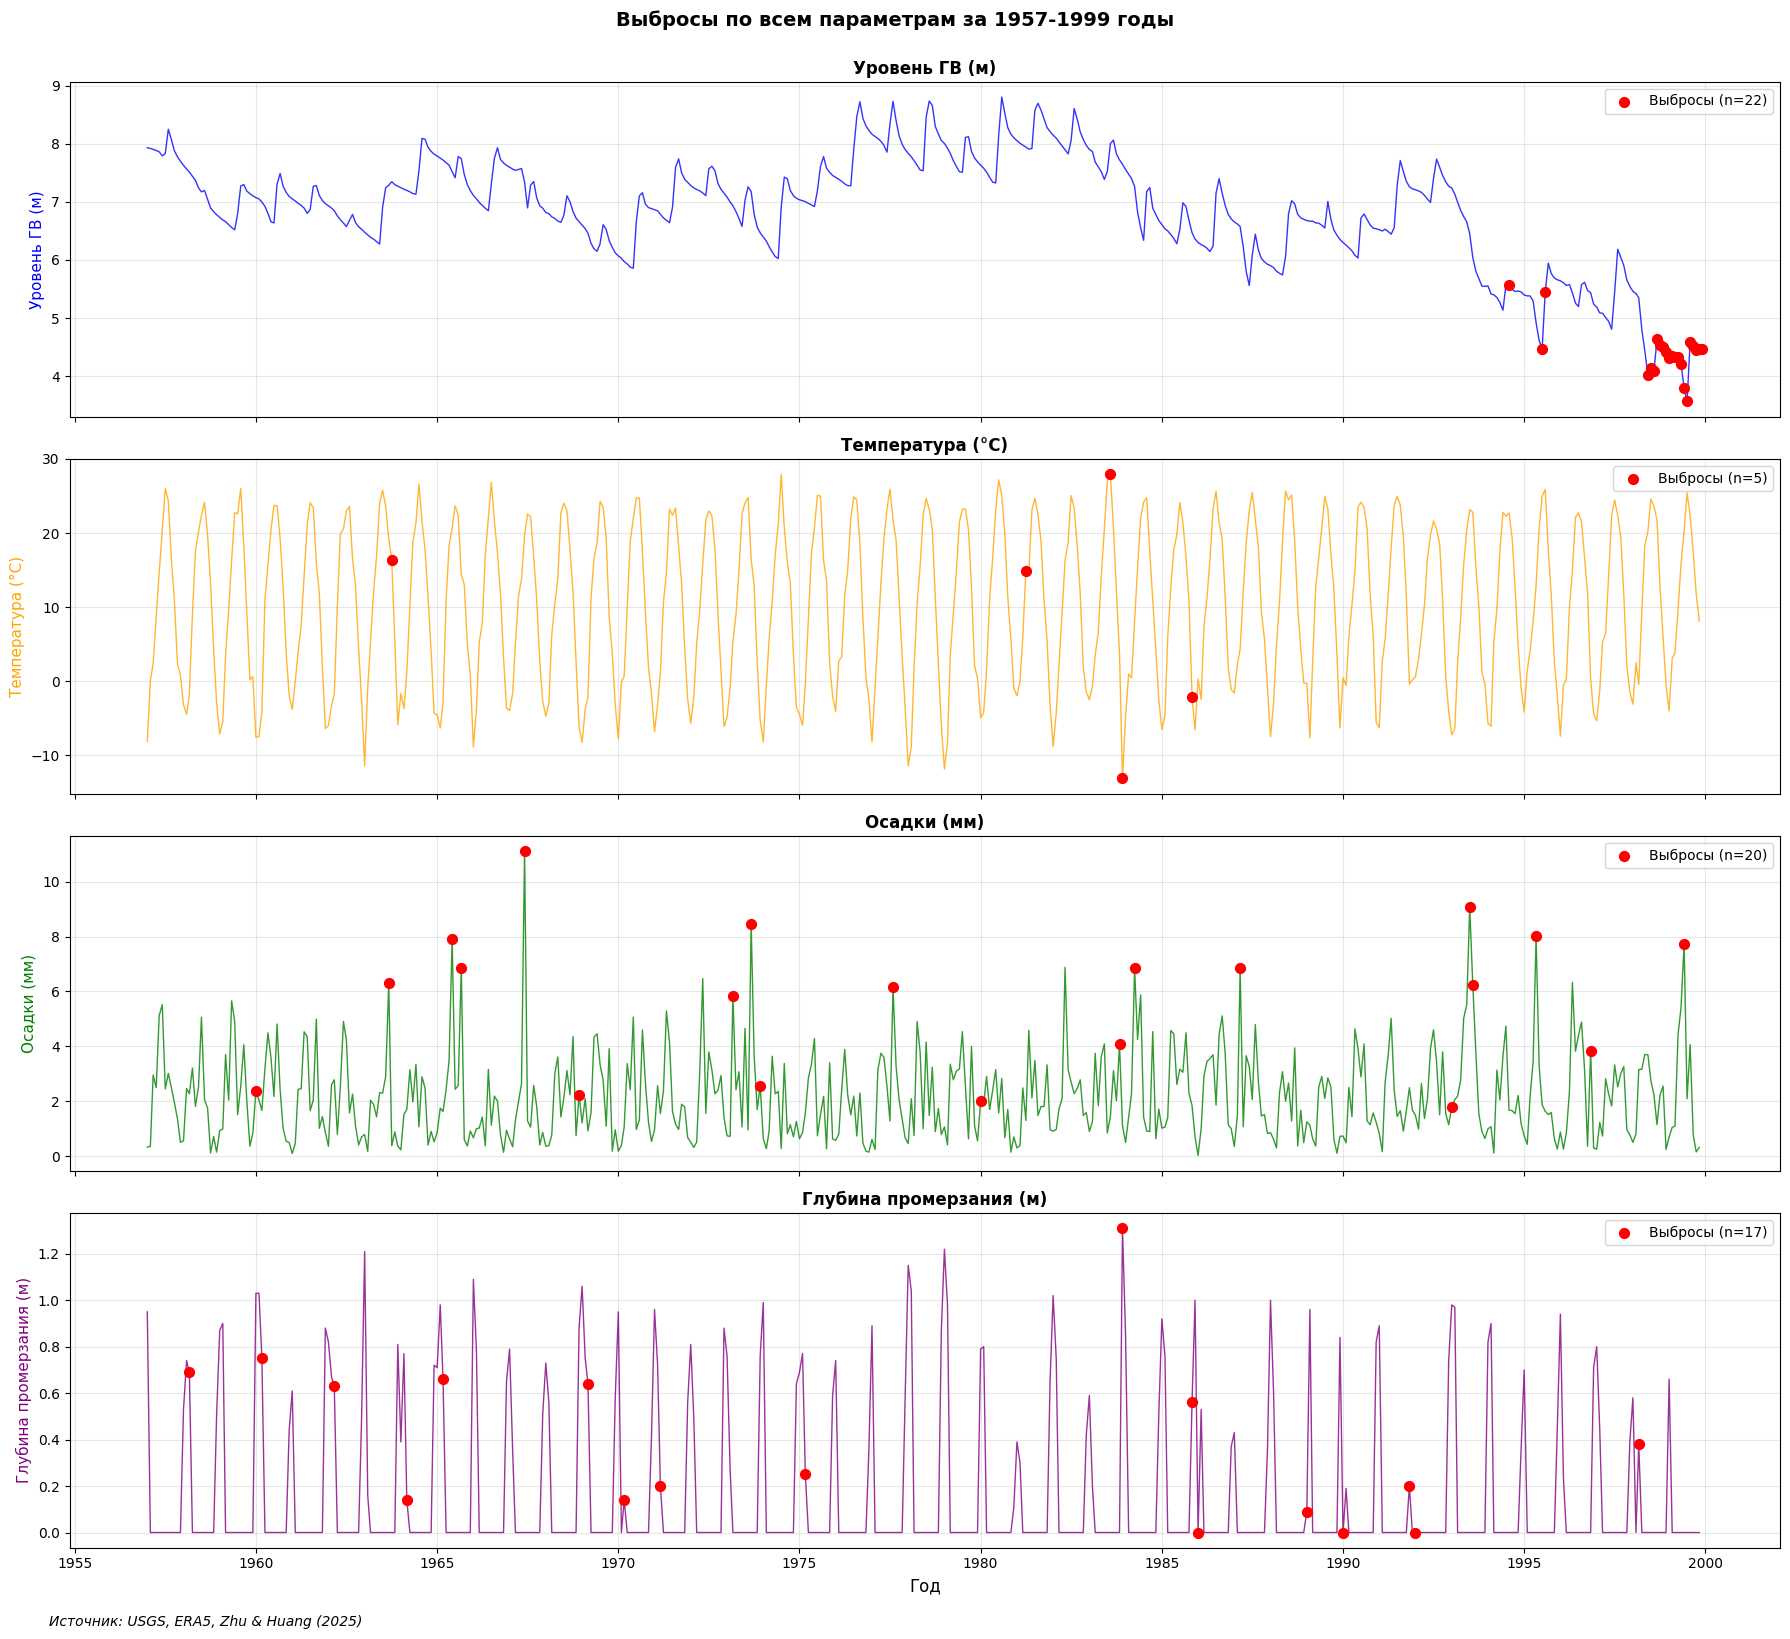

In [65]:
# Создаем 4 отдельных графика для каждого параметра
fig, axes = plt.subplots(4, 1, figsize=(18, 16), sharex=True)

colors = {'depth_m': 'blue', 'temp_C': 'orange', 'precip_mm': 'green', 'freeze_depth': 'purple'}
labels = {'depth_m': 'Уровень ГВ (м)', 'temp_C': 'Температура (°C)', 
          'precip_mm': 'Осадки (мм)', 'freeze_depth': 'Глубина промерзания (м)'}

for i, col in enumerate(numeric_cols):
    ax = axes[i]
    
    # Данные для текущего параметра
    data = all_outliers_combined[all_outliers_combined['parameter'] == col]
    
    # Сортируем данные по дате
    plot_data = nb_data[['month_start', 'year', 'month', col]].sort_values('month_start').copy().reset_index(drop=True)
    
    # Проверяем последовательность месяцев
    plot_data['is_gap'] = False
    for idx in range(1, len(plot_data)):
        prev_year = plot_data.loc[idx-1, 'year']
        prev_month = plot_data.loc[idx-1, 'month']
        curr_year = plot_data.loc[idx, 'year']
        curr_month = plot_data.loc[idx, 'month']
        
        # Ожидаемый следующий месяц
        if prev_month == 12:
            expected_year = prev_year + 1
            expected_month = 1
        else:
            expected_year = prev_year
            expected_month = prev_month + 1
        
        # Проверяем совпадение
        if not (curr_year == expected_year and curr_month == expected_month):
            plot_data.loc[idx, 'is_gap'] = True
    
    # Рисуем сегменты между пропусками
    segment_start = 0
    for idx in range(len(plot_data)):
        if plot_data['is_gap'].iloc[idx] or idx == len(plot_data) - 1:
            # Рисуем сегмент от segment_start до idx
            segment = plot_data.iloc[segment_start:idx]
            if len(segment) > 0:
                ax.plot(segment['month_start'], segment[col], 
                       color=colors[col], alpha=0.8, linewidth=1)
            segment_start = idx
    
    # Добавляем выбросы красными точками
    n_outliers = len(data)
    if n_outliers > 0:
        ax.scatter(data['datetime'], data['value'], color='red', s=50, zorder=5, 
                   label=f'Выбросы (n={n_outliers})')
    
    ax.set_ylabel(labels[col], color=colors[col], fontsize=11)
    ax.set_title(f'{labels[col]}', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right')

axes[-1].set_xlabel('Год', fontsize=12)
plt.suptitle('Выбросы по всем параметрам за 1957-1999 годы', fontsize=14, fontweight='bold', y=1.0)
fig.text(0.03, -0.01, 'Источник: USGS, ERA5, Zhu & Huang (2025)', ha='left', fontsize=10, style='italic')
plt.tight_layout()
plt.savefig('../visualizations/outliers_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

Проанализируем выбросы для каждого признака отдельно.

In [66]:
all_outliers_combined[all_outliers_combined['parameter'] == 'depth_m'].sort_values('year')

,parameter,year,month,value,lower_bound,upper_bound,datetime
0,depth_m,1994,8,5.571744,5.572633,9.076817,1994-08-01
1,depth_m,1995,7,4.474464,5.151719,8.847201,1995-07-01
2,depth_m,1995,8,5.443728,5.572633,9.076817,1995-08-01
3,depth_m,1998,6,4.029456,4.379858,8.985023,1998-06-01
4,depth_m,1998,7,4.142232,5.151719,8.847201,1998-07-01
5,depth_m,1998,8,4.084320,5.572633,9.076817,1998-08-01
6,depth_m,1998,9,4.639056,5.070203,9.524347,1998-09-01
7,depth_m,1998,10,4.532376,5.076535,9.197866,1998-10-01
8,depth_m,1998,11,4.501896,4.892503,9.205495,1998-11-01
9,depth_m,1998,12,4.416552,4.727217,9.227146,1998-12-01


Глубина грунтовых вод (depth_m). Выявлено 22 выброса. Сконцентрированы в пределах последних 5-ти лет наблюдений в данной выборке. Отклонения локальны, физически обоснованы и незначительно отличаются от нормального диапазона значений. Можно предположить что данные выбросы связаны с изменениями происходящими в климатических процессах, а также в увеличившийся техногенной нагрузке. Данные отклонения имеют естественную природу и не связаны с погрешностями измерений. 

In [67]:
all_outliers_combined[all_outliers_combined['parameter'] == 'temp_C'].sort_values('month')

,parameter,year,month,value,lower_bound,upper_bound,datetime
60,temp_C,1981,4,14.940698,6.027361,14.261430,1981-04-01
61,temp_C,1983,8,27.952386,19.544916,27.083002,1983-08-01
59,temp_C,1963,10,16.371790,8.463739,15.199091,1963-10-01
63,temp_C,1985,11,-2.122870,-1.816191,8.139070,1985-11-01
62,temp_C,1983,12,-13.094946,-9.483801,4.215173,1983-12-01


Температура воздуха (temp_C). Зарегистрировано 5 выбросов. Аномалии локальны, соответствуют физически возможным значениям и наблюдаются в ближайших временных интервалах. Локальные температурные всплески/провалы типичны и не считаются «классическими» выбросами.

In [68]:
all_outliers_combined[all_outliers_combined['parameter'] == 'precip_mm'].sort_values('month')

,parameter,year,month,value,lower_bound,upper_bound,datetime
39,precip_mm,1960,1,2.386729,0.0,1.581271,1960-01-01
49,precip_mm,1980,1,2.004835,0.0,1.581271,1980-01-01
53,precip_mm,1993,1,1.798418,0.0,1.581271,1993-01-01
45,precip_mm,1973,3,5.845600,0.0,5.260997,1973-03-01
52,precip_mm,1987,3,6.839752,0.0,5.260997,1987-03-01
51,precip_mm,1984,4,6.846958,0.0,5.334324,1984-04-01
56,precip_mm,1995,5,8.011288,0.0,7.822037,1995-05-01
43,precip_mm,1967,6,11.106491,0.0,7.116318,1967-06-01
58,precip_mm,1999,6,7.734511,0.0,7.116318,1999-06-01
41,precip_mm,1965,6,7.907867,0.0,7.116318,1965-06-01


Осадки (precip_mm). Выявлено 20 выброса. Отклонения локальны, физически возможны и преимущественно приходятся на летний и зимний периоды. Как и в случае с температурой, локальные аномалии осадков — норма для климатических данных.

In [69]:
all_outliers_combined[all_outliers_combined['parameter'] == 'freeze_depth'].sort_values('month')

,parameter,year,month,value,lower_bound,upper_bound,datetime
34,freeze_depth,1989,1,0.09,0.155,1.4350,1989-01-01
35,freeze_depth,1990,1,0.00,0.155,1.4350,1990-01-01
37,freeze_depth,1992,1,0.00,0.155,1.4350,1992-01-01
33,freeze_depth,1986,1,0.00,0.155,1.4350,1986-01-01
22,freeze_depth,1958,3,0.69,0.000,0.0000,1958-03-01
23,freeze_depth,1960,3,0.75,0.000,0.0000,1960-03-01
24,freeze_depth,1962,3,0.63,0.000,0.0000,1962-03-01
25,freeze_depth,1964,3,0.14,0.000,0.0000,1964-03-01
29,freeze_depth,1971,3,0.20,0.000,0.0000,1971-03-01
28,freeze_depth,1970,3,0.14,0.000,0.0000,1970-03-01


In [70]:
all_outliers_combined[all_outliers_combined['parameter'] == 'freeze_depth'].value_counts('month')

month
3     10
1      4
11     2
12     1
Name: count, dtype: int64

In [71]:
# Выбросы глубины промерзания с соответствующими значениями температуры и осадков
freeze_outliers = all_outliers_combined[all_outliers_combined['parameter'] == 'freeze_depth'].copy()

# Добавляем температуру и осадки для этих дат
freeze_outliers = freeze_outliers.merge(
    nb_data[['year', 'month', 'temp_C', 'precip_mm']], 
    on=['year', 'month'], 
    how='left'
)

freeze_outliers = freeze_outliers.sort_values(['year', 'month'])[
    ['year', 'month', 'value', 'temp_C', 'precip_mm', 'lower_bound', 'upper_bound']
]
freeze_outliers.sort_values('month')

,year,month,value,temp_C,precip_mm,lower_bound,upper_bound
12,1989,1,0.09,-0.287146,1.253022,0.155,1.4350
13,1990,1,0.00,0.470941,0.735919,0.155,1.4350
15,1992,1,0.00,0.615991,1.491970,0.155,1.4350
11,1986,1,0.00,0.313043,0.028398,0.155,1.4350
0,1958,3,0.69,-1.798865,2.273983,0.000,0.0000
1,1960,3,0.75,-4.001898,1.665539,0.000,0.0000
2,1962,3,0.63,-1.704810,2.782398,0.000,0.0000
3,1964,3,0.14,1.245142,1.700931,0.000,0.0000
7,1971,3,0.20,1.191797,1.559469,0.000,0.0000
6,1970,3,0.14,0.697443,1.056671,0.000,0.0000


Глубина промерзания (freeze_depth). Обнаружено 17 аномальных значений с чёткой сезонной привязкой: пик выбросов — март, дополнительные всплески — январь, ноябрь, декабрь. Отклонения обусловлены климатическими колебаниями и соответствуют естественным процессам.

Все выявленные выбросы имеют физическое обоснование, отражают реальную вариативность природных процессов и не являются результатом ошибок измерения/расчёта. 

Таким образом, выбросы следует сохранить в анализе, так как они несут важную информацию для построения модели.

### 1.4 EDA

In [72]:
nb_data.head(3)

,site_no,year,month,depth_m,delta_depth_m,month_start,temp_C,precip_mm,freeze_depth
0,404618098504401,1957,1,7.930896,NaN,1957-01-01,-8.095496,0.331031,0.95
1,404618098504401,1957,2,7.918704,-0.012192,1957-02-01,0.082910,0.364621,0.00
2,404618098504401,1957,3,7.901940,-0.016764,1957-03-01,2.376733,2.955543,0.00


Проверим данные на стационарность.

In [73]:
numeric_cols_stat = ['delta_depth_m', 'depth_m', 'temp_C', 'precip_mm', 'freeze_depth']

In [74]:
# Тест Дики-Фуллера
for col in numeric_cols_stat:
    test = adfuller(nb_data[col].dropna(), autolag='AIC', regression='ct')
    
    print(f"{col}: ADF statistic: {test[0]:.4f}; p-value: {test[1]:.4f}")
    print("Critical values:")
    for key, value in test[4].items():
        print(f"{key}: {value:.4f}")    
    if test[0] > test[4]["5%"]:
        print("Ряд нестационарен",'\n')
    else:
        print("Ряд стационарен",'\n')   

delta_depth_m: ADF statistic: -5.5429; p-value: 0.0000
Critical values:
1%: -3.9770
5%: -3.4193
10%: -3.1322
Ряд стационарен 

depth_m: ADF statistic: -2.3647; p-value: 0.3985
Critical values:
1%: -3.9770
5%: -3.4193
10%: -3.1322
Ряд нестационарен 

temp_C: ADF statistic: -6.1564; p-value: 0.0000
Critical values:
1%: -3.9771
5%: -3.4194
10%: -3.1323
Ряд стационарен 

precip_mm: ADF statistic: -5.9765; p-value: 0.0000
Critical values:
1%: -3.9770
5%: -3.4193
10%: -3.1322
Ряд стационарен 

freeze_depth: ADF statistic: -7.3293; p-value: 0.0000
Critical values:
1%: -3.9771
5%: -3.4194
10%: -3.1323
Ряд стационарен 



Построим диаграмму сезонной декомпозиции.

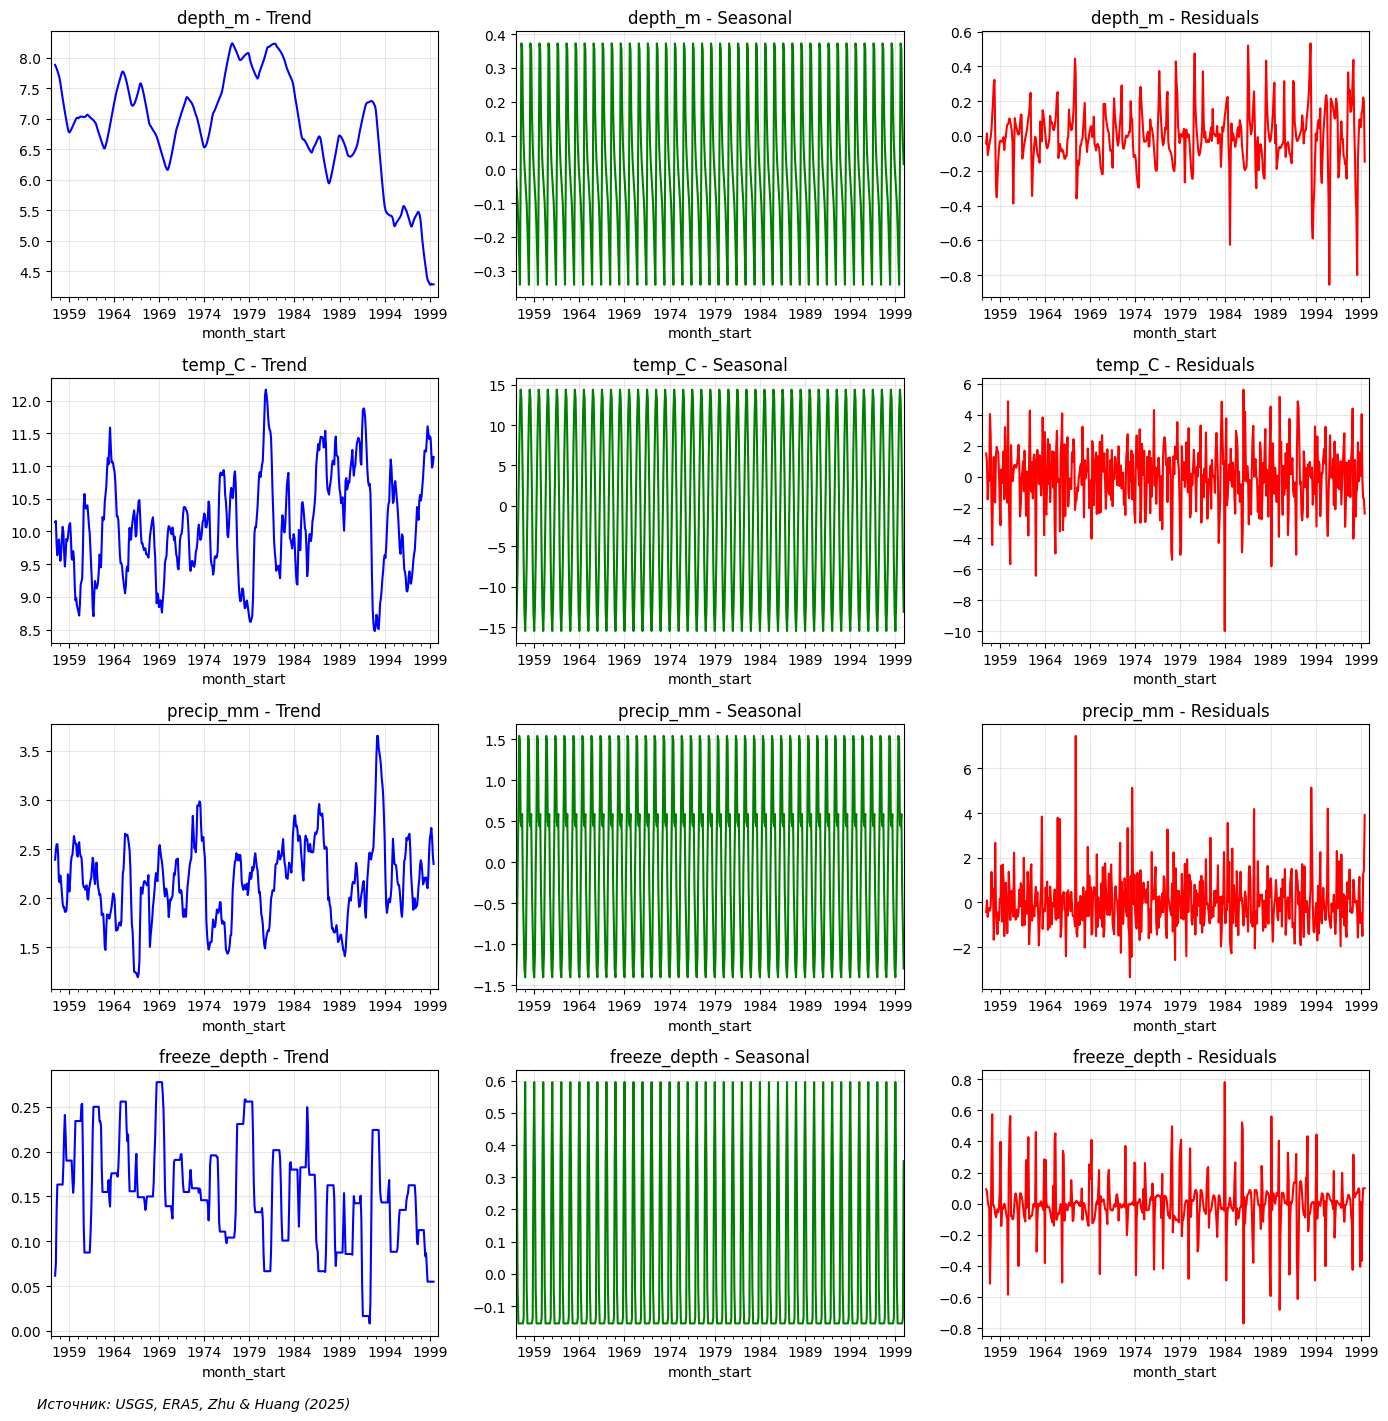

In [75]:
fig, axes = plt.subplots(4, 3, figsize=(14, 14))

for i, col in enumerate(numeric_cols_stat[1:]):
    decom = nb_data[col].set_axis(nb_data['month_start'])
    decomposition = seasonal_decompose(decom, model='additive', period=12)
    
    decomposition.trend.plot(ax=axes[i, 0], color='blue')
    axes[i, 0].set_title(f'{col} - Trend')
    axes[i, 0].grid(True, alpha=0.3)
    
    decomposition.seasonal.plot(ax=axes[i, 1], color='green')
    axes[i, 1].set_title(f'{col} - Seasonal')
    axes[i, 1].grid(True, alpha=0.3)
    
    decomposition.resid.plot(ax=axes[i, 2], color='red')
    axes[i, 2].set_title(f'{col} - Residuals')
    axes[i, 2].grid(True, alpha=0.3)

plt.tight_layout()
fig.text(0.03, -0.01, 'Источник: USGS, ERA5, Zhu & Huang (2025)', ha='left', fontsize=10, style='italic')
plt.savefig('../visualizations/seasonal_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()

Анализ сезонной декомпозиции временных рядов показал:

- depth_m: волнообразный тренд, умеренная сезонность, малые остатки;

- temp_C: восходящий тренд с колебаниями, яркая сезонность, значительные остатки (экстремальные условия);

- precip_mm: слабый тренд, чёткая сезонность (влажные/сухие сезоны), высокие остатки (низкая предсказуемость);

- freeze_depth: стабильный тренд, выраженная сезонность (зимние максимумы), малые остатки.

Тренды в данных имеют разную выраженность: от стабильных (freeze_depth) до едва уловимых (precip_mm). Высокая вариабельность данных может маскировать слабые долгосрочные изменения. Для улучшения анализа применим сглаживание с помощью скользящего среднего (5 лет), чтобы снизить влияние краткосрочных колебаний.

In [76]:
# Скользящее среднее (5 лет)
yearly_means = nb_data.groupby('year')[numeric_cols_stat[1:]].mean()
rolling_5y = yearly_means.rolling(window=5, min_periods=5, center=True).mean().dropna()

# Статистический тест Кендалла-Тау для оценки монотонного тренда
for col in numeric_cols_stat[1:]:
    tau, p = stats.kendalltau(rolling_5y.index, rolling_5y[col])
    trend = "+" if tau > 0 else "-"
    sig = "значимый" if p < 0.05 else "незначимый"
    direction = "повышение" if tau > 0 else "понижение"
    
    print(f"{col}: τ = {tau:+.3f}, p = {p:.4f} ({sig}; {trend} тренд)")
    
    if p < 0.05:
        print(f"Значимый тренд на {direction}")


depth_m: τ = -0.341, p = 0.0022 (значимый; - тренд)
Значимый тренд на понижение
temp_C: τ = +0.460, p = 0.0000 (значимый; + тренд)
Значимый тренд на повышение
precip_mm: τ = +0.306, p = 0.0060 (значимый; + тренд)
Значимый тренд на повышение
freeze_depth: τ = -0.643, p = 0.0000 (значимый; - тренд)
Значимый тренд на понижение


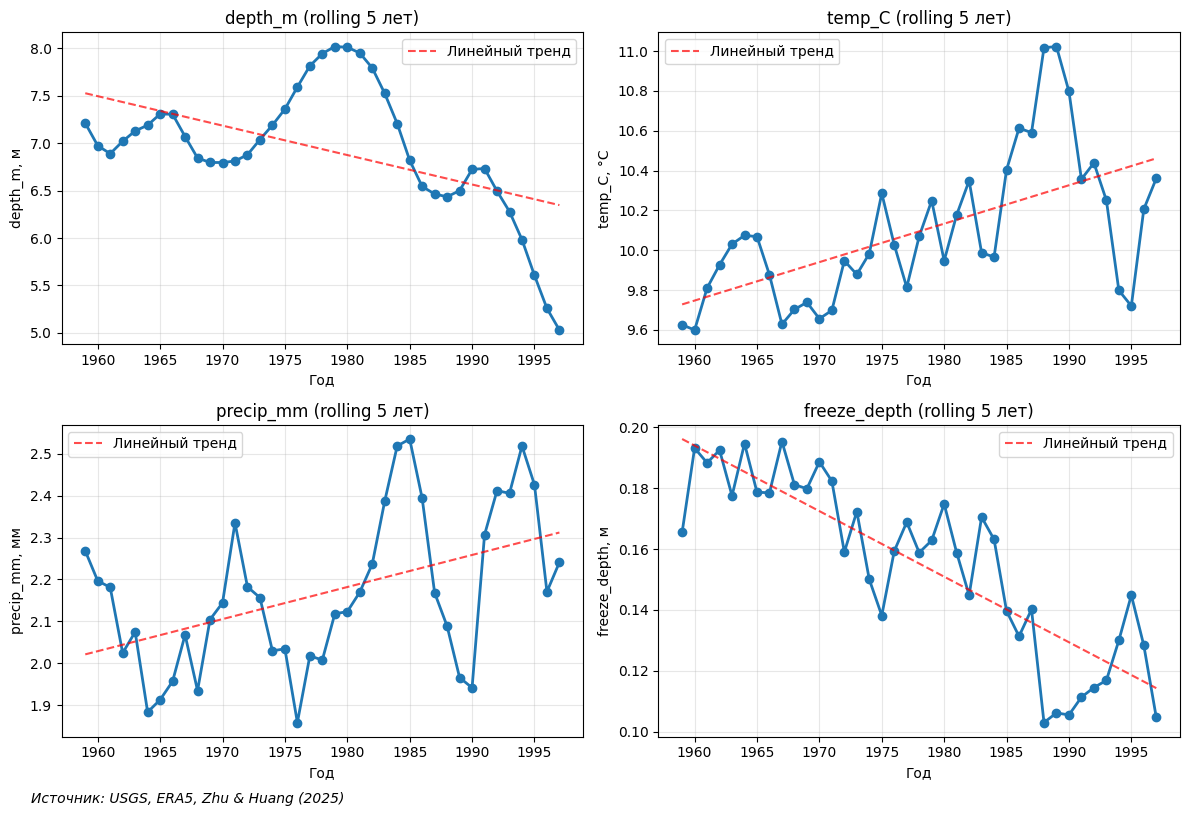

In [77]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for i, col in enumerate(numeric_cols_stat[1:]):
    ax = axes[i//2, i%2]
    ax.plot(rolling_5y.index, rolling_5y[col], 'o-', linewidth=2, markersize=6)
    
    # Линия тренда
    z = np.polyfit(rolling_5y.index, rolling_5y[col], 1)
    p = np.poly1d(z)
    ax.plot(rolling_5y.index, p(rolling_5y.index), 'r--', alpha=0.7, label='Линейный тренд')
    
    ax.set_title(f'{col} (rolling 5 лет)')
    ax.set_xlabel('Год')
    ax.set_ylabel(f'{col}, {units[col]}')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
fig.text(0.03, -0.01, 'Источник: USGS, ERA5, Zhu & Huang (2025)', ha='left', fontsize=10, style='italic')
plt.savefig('../visualizations/rolling_5y_trend.png', dpi=150, bbox_inches='tight')
plt.show()

После применения скользящего среднего с окном 5 лет для сглаживания данных наличие долгосрочных монотонных трендов в рядах подтверждается как статистически (тест Кендалла-Тау), так и визуально по графикам с наложенной линейной регрессией. При этом:

- уровень грунтовых вод и глубина промерзания демонстрируют отрицательный тренд;

- температура и суммарные осадки показывают положительный тренд.

Тем не менее, несмотря на выявленные долгосрочные тренды, временные ряды характеризуются выраженной сезонной и краткосрочной вариабельностью. Поскольку для прогнозирования текущего уровня грунтовых вод определяющее значение имеет влияние предшествующих значений, необходимо провести анализ лагов за последние месяцы и сформировать соответствующие признаки для модели. 

Для этого будет произведет корреляционный анализ лагов `delta_depth_m` и анализ влияния лагов признаков (температуры, осадков, глубины промерзания) на `delta_depth_m`. 

 Построим коррелограммы ACF и PACF для анализа корреляции ряда `delta_depth_m` с его прошлыми значениями.

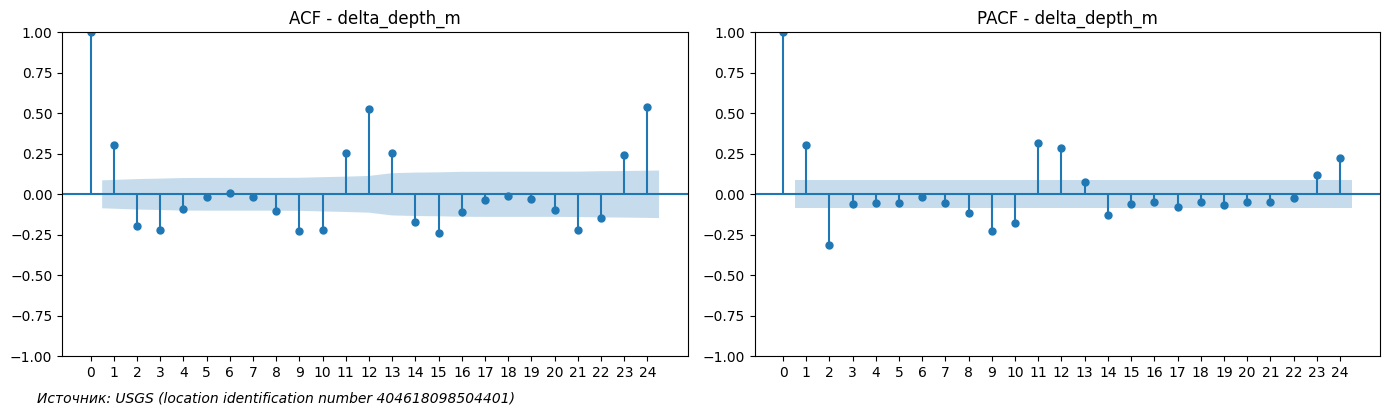

In [78]:
# Коррелограммы ACF и PACF для delta_depth_m

plt.rcParams["figure.figsize"] = 14, 10

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    
sgt.plot_acf(nb_data['delta_depth_m'].dropna(), ax=axes[0], lags=24, zero=True, title=f'ACF - delta_depth_m')
sgt.plot_pacf(nb_data['delta_depth_m'].dropna(), ax=axes[1], lags=24, method="ywm", zero=True, title=f'PACF - delta_depth_m')
    
# Устанавливаем деления от 1 до 24
for ax in axes:
    ax.set_xticks(range(0, 25, 1))
    
# Добавляем подпись источника
fig.text(0.03, -0.02, 'Источник: USGS (location identification number 404618098504401)', 
         ha='left', fontsize=10, style='italic')    
plt.tight_layout()
plt.savefig(f'../visualizations/acf_pacf_delta_depth_m.png', dpi=150, bbox_inches='tight')
plt.show()

По графику ACF ряд имеет значимую автокорреляцию на коротких лагах (1–3), по PACF - основная зависимость в ряду формируется на лагах 1–2. Таким образом, ряд `delta_depth_m` имеет значимую краткосрочную зависимость между наблюдениями на лагах 1–2. Значимыми также являются лаги 8-12 и 23-24, указывающие на наличие сезонности, где максимальные значения корреляции достогаются на лагах 11 и 24.

Для анализа влиянияния `'temp_C', 'precip_mm', 'freeze_depth'` на `'delta_depth_m'` построим тепловую карту корреляции лагов признаков и `'delta_depth_m'`.

In [79]:
# Расчёт корреляций лагов 1-24 признаков с delta_depth_m (Спирман)

lags = np.arange(1, 25)

results = []
for lag in lags:
    # Сдвигаем признаки и удаляем NaN только для текущего лага
    df_temp = nb_data[['delta_depth_m', 'temp_C', 'precip_mm', 'freeze_depth']].copy()
    df_temp['temp_C_lag'] = df_temp['temp_C'].shift(lag)
    df_temp['precip_mm_lag'] = df_temp['precip_mm'].shift(lag)
    df_temp['freeze_depth_lag'] = df_temp['freeze_depth'].shift(lag)
    df_temp = df_temp.dropna()
    
    temp_r, temp_p = spearmanr(df_temp['delta_depth_m'], df_temp['temp_C_lag'])
    precip_r, precip_p = spearmanr(df_temp['delta_depth_m'], df_temp['precip_mm_lag'])
    freeze_r, freeze_p = spearmanr(df_temp['delta_depth_m'], df_temp['freeze_depth_lag'])
    
    results.append({
        'lag': lag,
        'temp_C': temp_r,
        'temp_p': temp_p,
        'Значимый_temp': temp_p < 0.05 if not np.isnan(temp_p) else False,
        'precip_mm': precip_r,
        'precip_p': precip_p,
        'Значимый_precip': precip_p < 0.05 if not np.isnan(precip_p) else False,
        'freeze_depth': freeze_r,
        'freeze_p': freeze_p,
		'Значимый_freeze': freeze_p < 0.05 if not np.isnan(freeze_p) else False
    })

corr_df = pd.DataFrame(results)

# Таблица с p-value
print("Корреляция Спирмана с delta_depth_m (лаги 1-24):")
display(corr_df[['lag', 'temp_C', 'temp_p', 'Значимый_temp', 'precip_mm', 'precip_p', 'Значимый_precip', 'freeze_depth', 'freeze_p', 'Значимый_freeze']].round(4))

Корреляция Спирмана с delta_depth_m (лаги 1-24):


,lag,temp_C,temp_p,Значимый_temp,precip_mm,precip_p,Значимый_precip,freeze_depth,freeze_p,Значимый_freeze
0,1,0.1582,0.0003,True,-0.1446,0.0010,True,0.0514,0.2440,False
1,2,-0.0262,0.5531,False,-0.0525,0.2348,False,0.0321,0.4679,False
2,3,-0.1623,0.0002,True,0.0332,0.4537,False,-0.0372,0.4011,False
3,4,-0.1895,0.0000,True,-0.0570,0.1982,False,-0.0662,0.1348,False
4,5,-0.1894,0.0000,True,-0.2173,0.0000,True,0.0810,0.0674,False
5,6,-0.1829,0.0000,True,-0.3091,0.0000,True,0.3497,0.0000,True
6,7,-0.1117,0.0117,True,-0.2818,0.0000,True,0.3478,0.0000,True
7,8,-0.0075,0.8666,False,-0.1017,0.0218,True,0.0346,0.4365,False
8,9,0.1375,0.0019,True,0.0806,0.0697,False,-0.3302,0.0000,True
9,10,0.2191,0.0000,True,0.1362,0.0021,True,-0.3686,0.0000,True


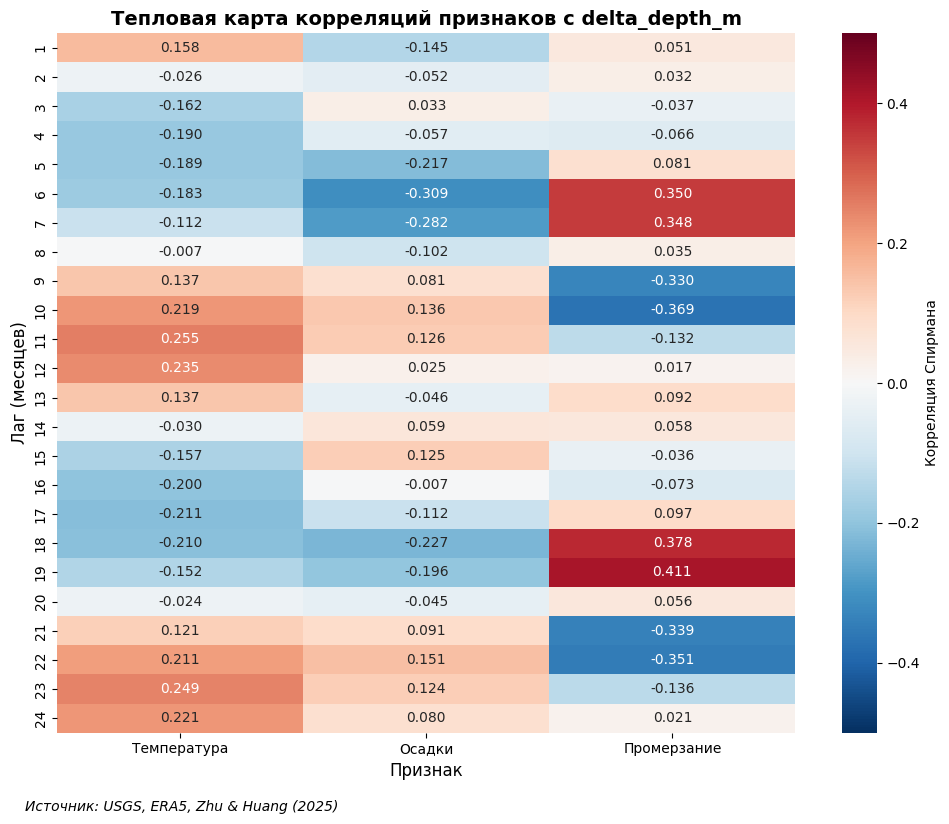

In [80]:
# Тепловая карта корреляций
import seaborn as sns

# Формируем данные для тепловой карты
heatmap_data = corr_df.set_index('lag')[['temp_C', 'precip_mm', 'freeze_depth']]
heatmap_data.columns = ['Температура', 'Осадки', 'Промерзание']

# Тепловая карта
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(heatmap_data, 
            annot=True, 
            fmt='.3f', 
            cmap='RdBu_r', 
            center=0,
            vmin=-0.5, 
            vmax=0.5,
            cbar_kws={'label': 'Корреляция Спирмана'},
            ax=ax)

ax.set_xlabel('Признак', fontsize=12)
ax.set_ylabel('Лаг (месяцев)', fontsize=12)
ax.set_title('Тепловая карта корреляций признаков с delta_depth_m', fontsize=14, fontweight='bold')

fig.text(0.03, -0.02, 'Источник: USGS, ERA5, Zhu & Huang (2025)', ha='left', fontsize=10, style='italic')
plt.tight_layout()
plt.savefig('../visualizations/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

Для лагов 1-24 будем считать, что значимые корреляций имеют умеренную силу ρ от 0.20 и надежность p < 0.05. Определим лаги, удовлетворяющие этим условиям.

In [81]:
def select_best_lags(lag_list, corr_df, feature):
    """Функция для выбора лагов с максимальной корреляцией из последовательных групп"""
    if not lag_list:
        return []
    
    lags = sorted(lag_list)
    
    # Группируем последовательности
    sequences = [[lags[0]]]
    for l in lags[1:]:
        if l == sequences[-1][-1] + 1:
            sequences[-1].append(l)
        else:
            sequences.append([l])
    
    # Выбираем лаг с max |корреляцией| из каждой группы
    result = []
    for s in sequences:
        subset = corr_df[corr_df['lag'].isin(s)].set_index('lag')[feature]
        best_lag = int(subset.abs().idxmax())
        result.append(best_lag)
    
    return sorted(result)

In [82]:
# Устанавливаем параметры
min_corr = 0.20
max_p = 0.05

# Создаем маски и получаем лаги
temp_C_lags_all = corr_df.loc[(corr_df['temp_C'].abs() >= min_corr) & 
                         (corr_df['temp_p'] < max_p), 'lag'].tolist()

precip_mm_lags_all = corr_df.loc[(corr_df['precip_mm'].abs() >= min_corr) & 
                            (corr_df['precip_p'] < max_p), 'lag'].tolist()

freeze_depth_lags_all = corr_df.loc[(corr_df['freeze_depth'].abs() >= min_corr) & 
                               (corr_df['freeze_p'] < max_p), 'lag'].tolist()

# Выбираем лучшие лаги из последовательных групп
temp_lags_eda = select_best_lags(temp_C_lags_all, corr_df, 'temp_C')
precip_lags_eda = select_best_lags(precip_mm_lags_all, corr_df, 'precip_mm')
freeze_lags_eda = select_best_lags(freeze_depth_lags_all, corr_df, 'freeze_depth')

# Выводим результаты
print("Все значимые лаги (|ρ| >= 0.20, p < 0.05):")
print(f"temp_C (все): {temp_C_lags_all}")
print(f"precip_mm (все): {precip_mm_lags_all}")
print(f"freeze_depth (все): {freeze_depth_lags_all}")

print("\nВыбранные лаги (из последовательных групп - с max корреляцией):")
print(f"temp_C: {temp_lags_eda}")
print(f"precip_mm: {precip_lags_eda}")
print(f"freeze_depth: {freeze_lags_eda}")

Все значимые лаги (|ρ| >= 0.20, p < 0.05):
temp_C (все): [10, 11, 12, 17, 18, 22, 23, 24]
precip_mm (все): [5, 6, 7, 18]
freeze_depth (все): [6, 7, 9, 10, 18, 19, 21, 22]

Выбранные лаги (из последовательных групп - с max корреляцией):
temp_C: [11, 17, 23]
precip_mm: [6, 18]
freeze_depth: [6, 10, 19, 22]


In [83]:
# Из всех выбранных лагов выбираем один с максимальной корреляцией
def get_best_from_all(lags, corr_df, feature):
    if not lags:
        return None, None
    subset = corr_df[corr_df['lag'].isin(lags)].set_index('lag')[feature]
    best_lag = subset.abs().idxmax()
    return int(best_lag), subset[best_lag]

# Один лучший лаг для каждого признака
temp_best, temp_corr = get_best_from_all(temp_lags_eda, corr_df, 'temp_C')
precip_best, precip_corr = get_best_from_all(precip_lags_eda, corr_df, 'precip_mm')
freeze_best, freeze_corr = get_best_from_all(freeze_lags_eda, corr_df, 'freeze_depth')

print("\nЛучшие лаги (1 лаг из каждого признака):")
print(f"temp_C: [{temp_best}] → ρ = {temp_corr:+.4f}")
print(f"precip_mm: [{precip_best}] → ρ = {precip_corr:+.4f}")
print(f"freeze_depth: [{freeze_best}] → ρ = {freeze_corr:+.4f}")


Лучшие лаги (1 лаг из каждого признака):
temp_C: [11] → ρ = +0.2549
precip_mm: [6] → ρ = -0.3091
freeze_depth: [19] → ρ = +0.4112


Лаги первых трех-четырех месяцев для признаков осадков и глубины промерзания практически не показали статистической значимой корреляции с `delta_depth_m`. Наиболее значимые лаги: для признака температуры 11-й лаг, для признака осадков - 6-й лаг, для глубины промерзания - 19-й лаг. Это соответствует физическому процессу, при котором уровень грунтовых реагирует на климатические факторы с задержкой.

**Вывод:**

На этапе анализа данных (EDA) были выполнены: очистка данных, проверка на выбросы и аномалии, seasonal decomposition, построение лагов для признаков и оценка их корреляции с `delta_depth_m`.

Результаты анализа показали, что определённые лаги температуры, осадков, промерзания и `delta_depth_m` оказывают статистически значимое влияние на текущий уровень грунтовых вод.


### 1.5 Feature engenering

#### 1.5.1 Числовые признаки

Выявленные по результатам анализа данных зависимости будут использованы при создании признаков для предсказания `delta_depth_m`.

В качестве целевой переменной будет использоваться `delta_depth_m`. Преобразование исходного ряда в разности (`delta_depth_m`) не изменило временную структуру данных, а изменило представление сигнала. А значит выявленные временные зависимости (лаги) сохраняются и переносятся на исходный ряд. Значение `depth_m` будет восстановлено путем сложения предсказанного значения `delta_depth_m` и 1-ого лага `depth_m`.

Будут созданы признаки для модели, включающее:

1. Лаги значимых признаков на основании корреляционного анализа.

2. Кумулятивные осадки для выявления накопительных эффектов.

3. Скользящие средние `depth_m, temp_C, precip_mm, freeze_depth`  для сглаживания краткосрочных колебаний.

4. Временные признаки (месяц, синус/косинус).

Этот набор признаков учитывает как физические, так и статистические закономерности, выявленные на этапе EDA, и предназначен для эффективного использования алгоритмами машинного обучения при прогнозировании текущего уровня грунтовых вод.



In [84]:
nb_data.head(3)

,site_no,year,month,depth_m,delta_depth_m,month_start,temp_C,precip_mm,freeze_depth
0,404618098504401,1957,1,7.930896,NaN,1957-01-01,-8.095496,0.331031,0.95
1,404618098504401,1957,2,7.918704,-0.012192,1957-02-01,0.082910,0.364621,0.00
2,404618098504401,1957,3,7.901940,-0.016764,1957-03-01,2.376733,2.955543,0.00


In [85]:
# Копируем данные
nb_data_model = nb_data.copy()

# 1. Скользящее среднее depth_m за 5 лет 
nb_data_model['depth_m_roll_5'] = nb_data_model['depth_m'].shift(1).rolling( window=5, min_periods=5).mean()

# 2. Скользящее среднее для признаков (5 лет)
nb_data_model['temp_C_roll_5'] = nb_data_model['temp_C'].shift(1).rolling(window=5, min_periods=5).mean()
nb_data_model['precip_mm_roll_5'] = nb_data_model['precip_mm'].shift(1).rolling(window=5, min_periods=5).mean()
nb_data_model['freeze_depth_roll_5'] = nb_data_model['freeze_depth'].shift(1).rolling(window=5, min_periods=5).mean()

# 3. Значимые лаги
temp_lags = temp_best
precip_lags = precip_best
freeze_lags = freeze_best

# Лаги для depth_m 
gw_lags = [1, 2, 11, 24]

# Лаги для depth_m
for lag in gw_lags:
    nb_data_model[f'depth_m_lag{lag}'] = nb_data_model['depth_m'].shift(lag)

# Лаги для температуры
nb_data_model[f'temp_C_lag{temp_best}'] = nb_data_model['temp_C'].shift(temp_best)

# Лаги для осадков
nb_data_model[f'precip_mm_lag{precip_lags}'] = nb_data_model['precip_mm'].shift(precip_lags)

 # Лаг для промерзания
nb_data_model[f'freeze_depth_lag{freeze_lags}'] = nb_data_model['freeze_depth'].shift(freeze_lags)

# 4. Кумулятивные осадки (3 и 6 месяцев)
nb_data_model['precip_cumsum_3'] = nb_data_model['precip_mm'].shift(1).rolling(window=3, min_periods=1).sum()
nb_data_model['precip_cumsum_6'] = nb_data_model['precip_mm'].shift(1).rolling(window=6, min_periods=1).sum()

# 5. Временные признаки для сезонности
nb_data_model['month_sin'] = np.sin(2 * np.pi * nb_data_model['month'] / 12)
nb_data_model['month_cos'] = np.cos(2 * np.pi * nb_data_model['month'] / 12)

# 6. Временные признаки для ряда данных
nb_data_model['time_ind'] = np.arange(len(nb_data_model))

In [86]:
# Удаляем строки с NaN 
nb_data_model = nb_data_model.dropna()
print('Размер после удаления NaN', nb_data_model.shape)

Размер после удаления NaN (492, 25)


In [87]:
nb_data_model.head(3)

,site_no,year,month,depth_m,delta_depth_m,month_start,temp_C,precip_mm,freeze_depth,depth_m_roll_5,...,depth_m_lag11,depth_m_lag24,temp_C_lag11,precip_mm_lag6,freeze_depth_lag19,precip_cumsum_3,precip_cumsum_6,month_sin,month_cos,time_ind
24,404618098504401,1959,1,6.733642,-0.044094,1959-01-01,-7.127722,0.931846,0.87,6.947611,...,7.564120,7.930896,-4.459814,5.065070,0.0,0.990762,9.865867,0.500000,8.660254e-01,24
25,404618098504401,1959,2,6.688836,-0.044806,1959-02-01,-5.447974,0.997119,0.90,6.855379,...,7.511796,7.918704,-1.798865,2.060784,0.0,1.801597,5.732642,0.866025,5.000000e-01,25
26,404618098504401,1959,3,6.658864,-0.029972,1959-03-01,3.524652,3.705343,0.00,6.785072,...,7.439660,7.901940,9.069543,1.749251,0.0,2.079010,4.668977,1.000000,6.123234e-17,26


In [88]:
nb_data_model.columns

Index(['site_no', 'year', 'month', 'depth_m', 'delta_depth_m', 'month_start',
       'temp_C', 'precip_mm', 'freeze_depth', 'depth_m_roll_5',
       'temp_C_roll_5', 'precip_mm_roll_5', 'freeze_depth_roll_5',
       'depth_m_lag1', 'depth_m_lag2', 'depth_m_lag11', 'depth_m_lag24',
       'temp_C_lag11', 'precip_mm_lag6', 'freeze_depth_lag19',
       'precip_cumsum_3', 'precip_cumsum_6', 'month_sin', 'month_cos',
       'time_ind'],
      dtype='object')

In [89]:
# Определим целевую переменную 
target = ['delta_depth_m']

# Определим только числовые признаки и удалим исходные признаки ('depth_m', 'temp_C', 'precip_mm', 'freeze_depth')
exclude_cols = ['site_no', 'month', 'year', 'month_start', 'depth_m', 'depth_m_lag1','temp_C', 'precip_mm', 'freeze_depth']

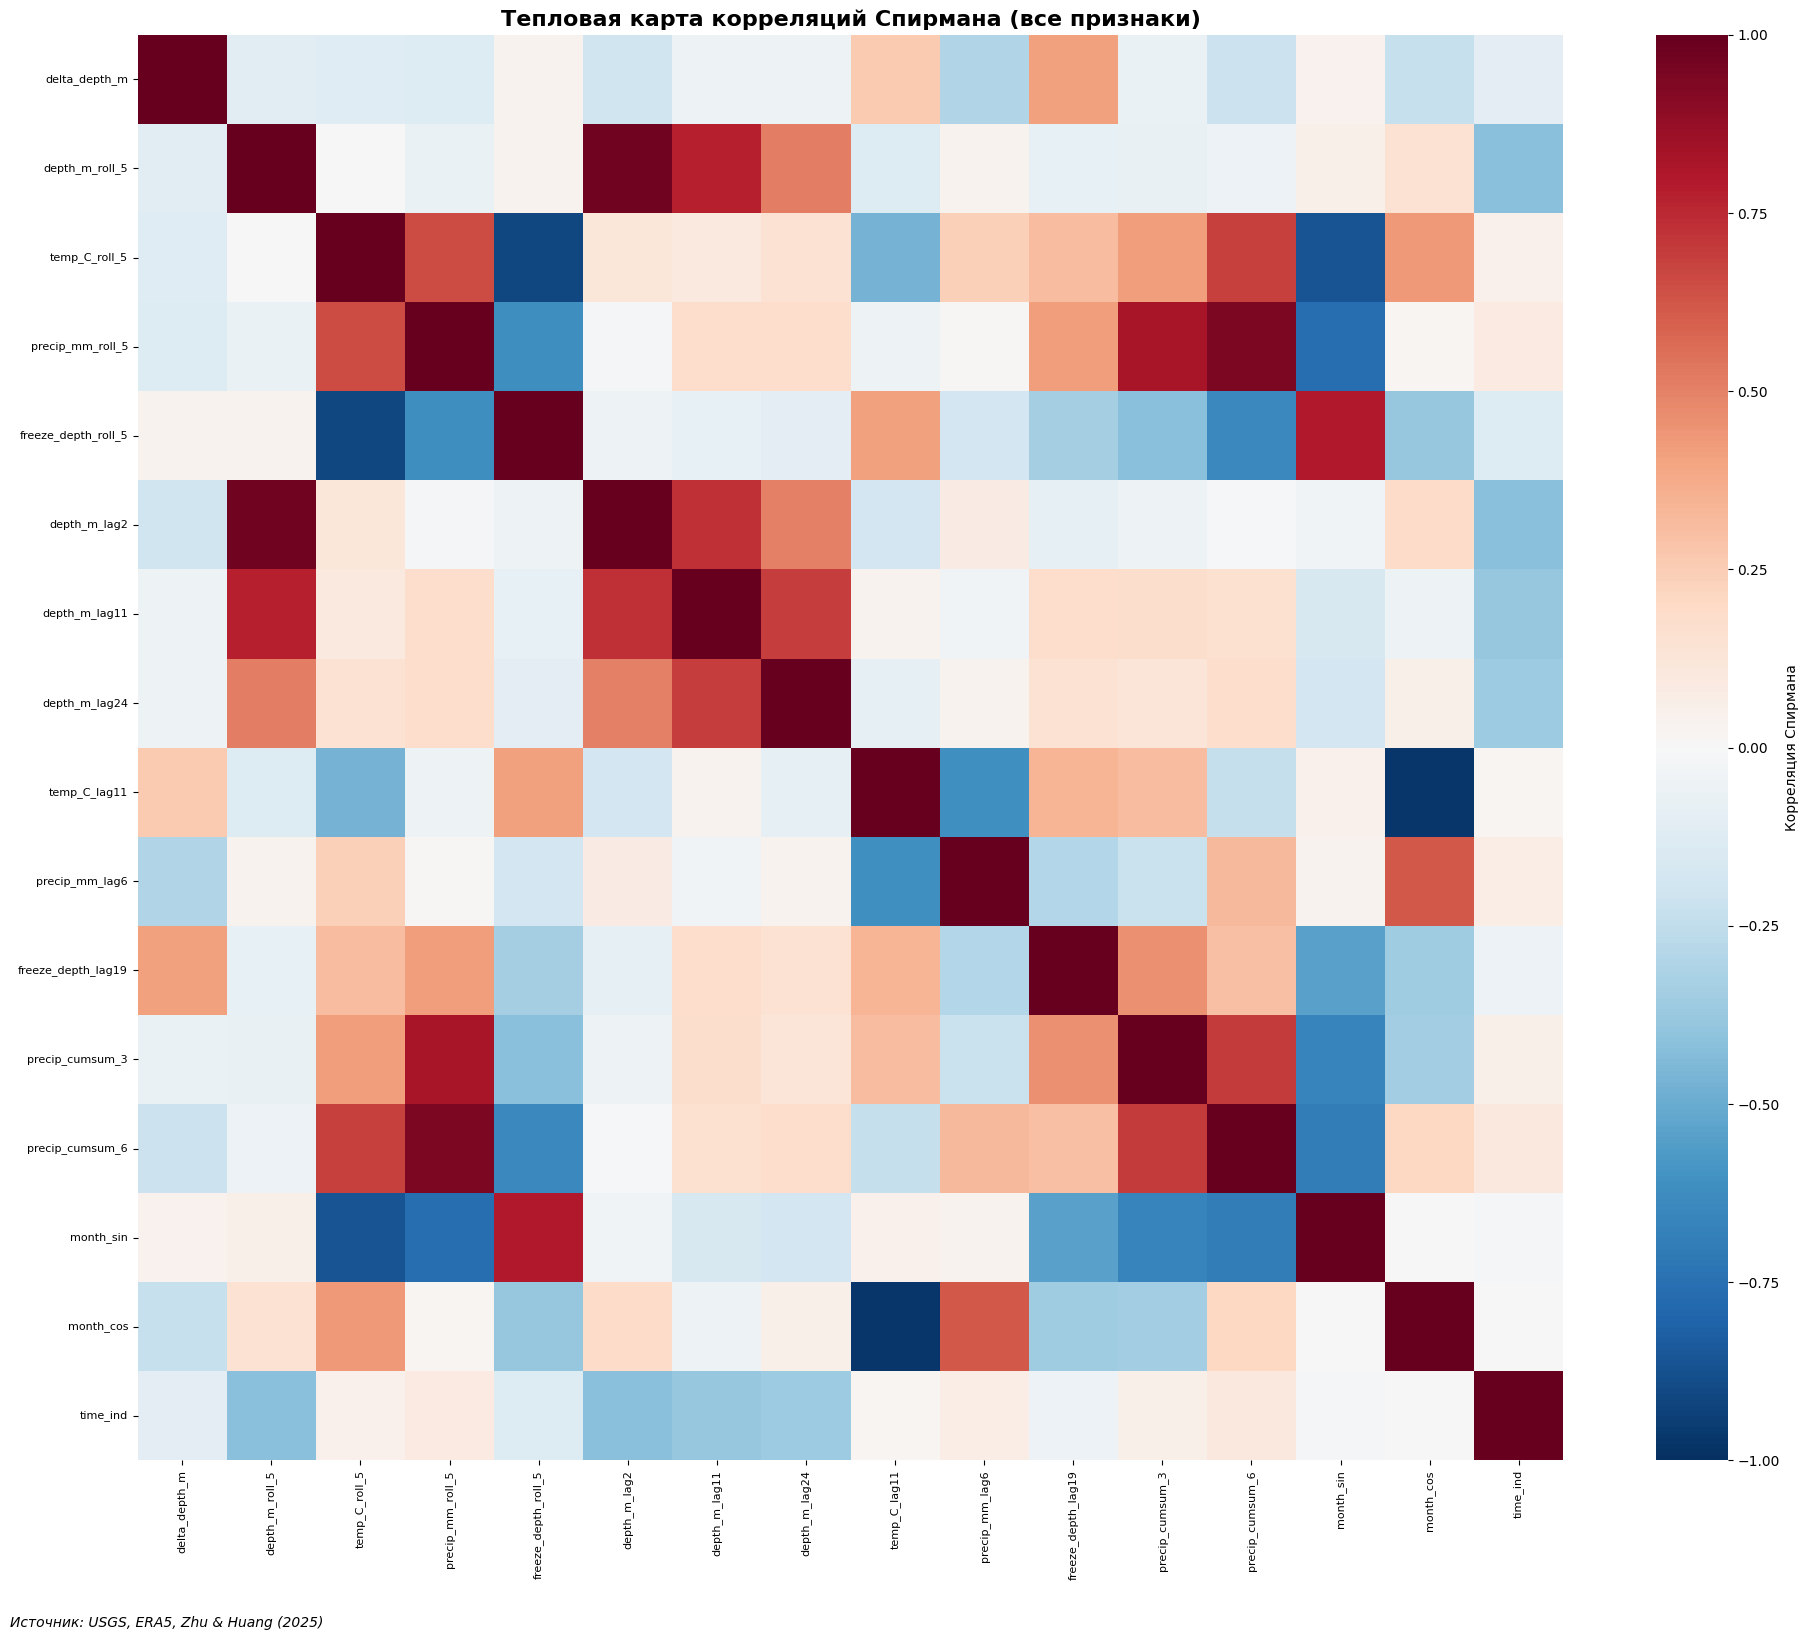

Количество признаков: 16


In [90]:
# Тепловая карта корреляций Спирмана для nb_data_model

# Вычисляем матрицу корреляций
corr_matrix = nb_data_model.drop(columns=exclude_cols).corr(method='spearman')

# Строим тепловую карту
fig, ax = plt.subplots(figsize=(20, 16))

sns.heatmap(corr_matrix, 
            annot=False, 
            cmap='RdBu_r', 
            center=0,
            vmin=-1, 
            vmax=1,
            square=True,
            cbar_kws={'label': 'Корреляция Спирмана'},
            ax=ax)

ax.set_title('Тепловая карта корреляций Спирмана (все признаки)', fontsize=16, fontweight='bold')
plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0, fontsize=8)

fig.text(0.03, -0.02, 'Источник: USGS, ERA5, Zhu & Huang (2025)', ha='left', fontsize=10, style='italic')
plt.tight_layout()
plt.savefig('../visualizations/correlation_heatmap_all.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Количество признаков: {len(nb_data_model.drop(columns=exclude_cols).columns)}")

In [91]:
# Извлекаем корреляцию с delta_depth_m
target_corr = corr_matrix['delta_depth_m'].drop('delta_depth_m').sort_values(key=abs, ascending=False)

# Добавляем p-value
results = []
for col in target_corr.index:
    rho = target_corr[col]
    try:
        _, p = spearmanr(nb_data_model.drop(columns=exclude_cols)[col], nb_data_model.drop(columns=exclude_cols)['delta_depth_m'])
    except:
        p = np.nan
    results.append({
        'Признак': col,
        'rho': round(rho,1),
        'abs_rho': round(abs(rho),1),
        'p_value': round(p,2),
        'Значимый': p < 0.05 if not np.isnan(p) else False
    })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values('abs_rho', ascending=False)

print("Корреляция с delta_depth_m:")
print(results_df.to_string(index=False))

Корреляция с delta_depth_m:
            Признак  rho  abs_rho  p_value  Значимый
 freeze_depth_lag19  0.4      0.4     0.00      True
     precip_mm_lag6 -0.3      0.3     0.00      True
       temp_C_lag11  0.3      0.3     0.00      True
          month_cos -0.2      0.2     0.00      True
    precip_cumsum_6 -0.2      0.2     0.00      True
       depth_m_lag2 -0.2      0.2     0.00      True
   precip_mm_roll_5 -0.1      0.1     0.00      True
      temp_C_roll_5 -0.1      0.1     0.01      True
     depth_m_roll_5 -0.1      0.1     0.01      True
           time_ind -0.1      0.1     0.02      True
    precip_cumsum_3 -0.1      0.1     0.15     False
      depth_m_lag11 -0.1      0.1     0.25     False
      depth_m_lag24 -0.1      0.1     0.26     False
          month_sin  0.0      0.0     0.37     False
freeze_depth_roll_5  0.0      0.0     0.43     False


In [92]:
# Проверка мультиколлинеарности
high_pairs = []

# Отфильтруем признаки с корреляцией rho >= 0.2 и  p < 0.05 с delta_depth_m
model_features = results_df[(results_df['Значимый'] == True) & (round(results_df['abs_rho'],1) >= 0.2)]['Признак'].to_list()
for i in range(len(model_features)):
    for j in range(i + 1, len(model_features)):
        feat1 = model_features[i]
        feat2 = model_features[j]
        
        # Корреляция между признаками
        correlation = nb_data_model[model_features][feat1].corr(nb_data_model[model_features][feat2], method = 'spearman')
        
        # Если корреляция высокая
        if round(abs(correlation), 1) >= 0.70:
            high_pairs.append((feat1, feat2, round(correlation,1)))

print(f"Пар с высокой корреляцией: {len(high_pairs)}")

Пар с высокой корреляцией: 1


In [93]:
high_pairs

[('temp_C_lag11', 'month_cos', np.float64(-1.0))]

In [94]:
#  Удаление признаков с мультиколлинеарностью

if high_pairs:
    print("Проблемные пары:")
    for feat1, feat2, corr in high_pairs:
        print(f"  {feat1} ↔ {feat2}: {corr:+.3f}")
    
    # Удаляем признаки
    to_remove = []
    
    for feat1, feat2, corr in high_pairs:
        print(f"Анализируем пару: {feat1} vs {feat2}")
        
        # Проверяем, что оба признака есть в results_df
        feat1_data = results_df[results_df['Признак'] == feat1]
        feat2_data = results_df[results_df['Признак'] == feat2]
        
        if len(feat1_data) == 0 or len(feat2_data) == 0:
            print(f"Пропускаем пару: один из признаков отсутствует в results_df")
            continue
        
        # Смотрим какая корреляция с target у каждого
        rho1 = abs(feat1_data['rho'].iloc[0])
        rho2 = abs(feat2_data['rho'].iloc[0])
        
        print(f"  {feat1} с target: {rho1:.3f}")
        print(f"  {feat2} с target: {rho2:.3f}")
        
        # Удаляем тот, что слабее связан с target
        if rho1 > rho2:
            to_remove.append(feat2)
            print(f"  Удаляем: {feat2}")
        elif rho2 > rho1:
            to_remove.append(feat1)
            print(f"  Удаляем: {feat1}")
        else:
            # Если корреляции равны, удаляем более простой признак
            if len(feat1) <= len(feat2):
                to_remove.append(feat1)
                print(f"Удаляем: {feat1} (равная корреляция, более простой)")
            else:
                to_remove.append(feat2)
                print(f"Удаляем: {feat2} (равная корреляция, более простой)")
    
    # Удаляем дубликаты из списка для удаления
    to_remove = list(set(to_remove))
    
    # Финальный список
    final_features = [f for f in model_features if f not in to_remove]
    
    
    print(f"Признаков для удаления: {len(to_remove)}")
    for feat in to_remove:
        feat_data = results_df[results_df['Признак'] == feat]
        if len(feat_data) > 0:
            rho = feat_data['rho'].iloc[0]
            print(f"	! Удален: {feat} (rho = {rho:+.3f})")
        else:
            print(f"	! Удален: {feat} (нет данных в results_df)")
    
    print(f"Финальный список признаков ({len(final_features)}):")
    for feat in final_features:
        feat_data = results_df[results_df['Признак'] == feat]
        if len(feat_data) > 0:
            rho = feat_data['rho'].iloc[0]
            print(f"	✓ {feat} (rho = {rho:+.3f})")
        else:
            print(f"	✓ {feat} (нет данных в results_df)")
            
else:
    final_features = model_features
    print("Мультиколлинеарность не найдена")

print(f"Итог: {len(model_features)} → {len(final_features)} признаков")

Проблемные пары:
  temp_C_lag11 ↔ month_cos: -1.000
Анализируем пару: temp_C_lag11 vs month_cos
  temp_C_lag11 с target: 0.300
  month_cos с target: 0.200
  Удаляем: month_cos
Признаков для удаления: 1
	! Удален: month_cos (rho = -0.200)
Финальный список признаков (5):
	✓ freeze_depth_lag19 (rho = +0.400)
	✓ precip_mm_lag6 (rho = -0.300)
	✓ temp_C_lag11 (rho = +0.300)
	✓ precip_cumsum_6 (rho = -0.200)
	✓ depth_m_lag2 (rho = -0.200)
Итог: 6 → 5 признаков


In [95]:
print('Финальное количество признаков:', len(final_features))

# Создаём финальный DataFrame 
nb_data_final = nb_data_model[['site_no', 'month_start', 'month', 'year'] +  target +  ['depth_m', 'depth_m_lag1'] + final_features]

print('Финальный размер данных:', nb_data_final.shape)

Финальное количество признаков: 5
Финальный размер данных: (492, 12)


In [96]:
nb_data_final.head(3)

,site_no,month_start,month,year,delta_depth_m,depth_m,depth_m_lag1,freeze_depth_lag19,precip_mm_lag6,temp_C_lag11,precip_cumsum_6,depth_m_lag2
24,404618098504401,1959-01-01,1,1959,-0.044094,6.733642,6.777736,0.0,5.065070,-4.459814,9.865867,6.831584
25,404618098504401,1959-02-01,2,1959,-0.044806,6.688836,6.733642,0.0,2.060784,-1.798865,5.732642,6.777736
26,404618098504401,1959-03-01,3,1959,-0.029972,6.658864,6.688836,0.0,1.749251,9.069543,4.668977,6.733642


In [97]:
nb_data_final.columns

Index(['site_no', 'month_start', 'month', 'year', 'delta_depth_m', 'depth_m',
       'depth_m_lag1', 'freeze_depth_lag19', 'precip_mm_lag6', 'temp_C_lag11',
       'precip_cumsum_6', 'depth_m_lag2'],
      dtype='object')

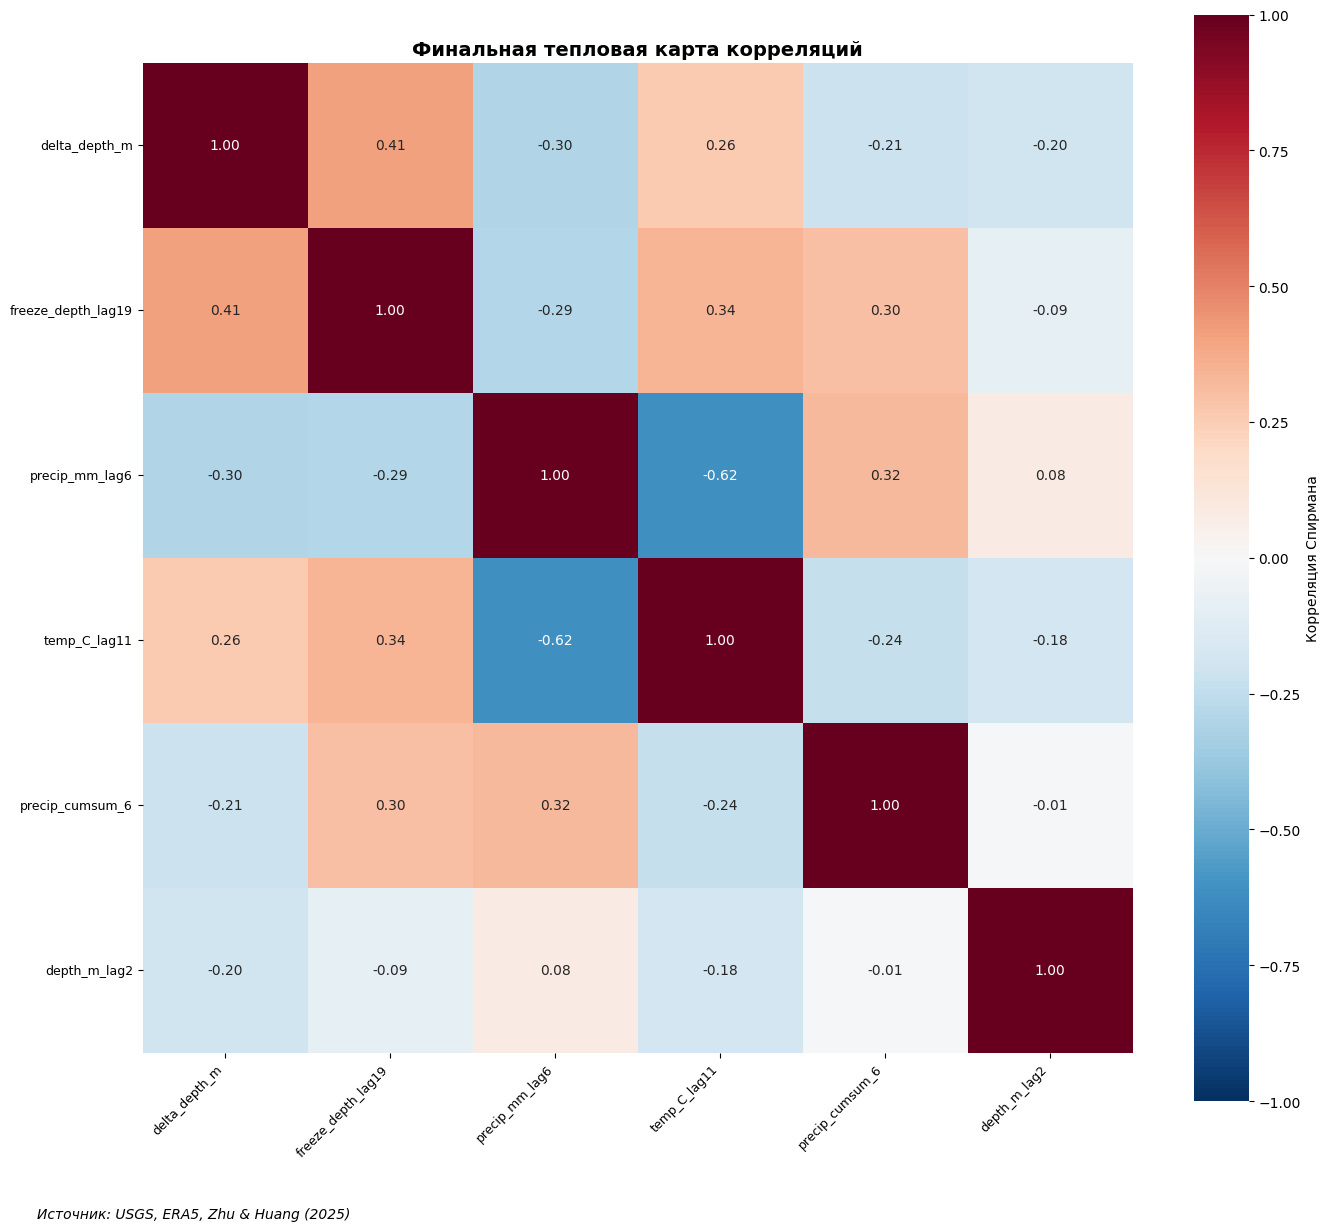

In [98]:
# Финальная тепловая карта

corr_final = nb_data_final.drop(columns = ['site_no', 'month_start', 'month', 'year', 'depth_m', 'depth_m_lag1']).corr(method='spearman')

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr_final, 
            annot=True, 
            fmt='.2f', 
            cmap='RdBu_r', 
            center=0,
            vmin=-1, 
            vmax=1,
            square=True,
            cbar_kws={'label': 'Корреляция Спирмана'},
            ax=ax)
ax.set_title('Финальная тепловая карта корреляций', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)

fig.text(0.03, -0.02, 'Источник: USGS, ERA5, Zhu & Huang (2025)', ha='left', fontsize=10, style='italic')
plt.tight_layout()
plt.savefig('../visualizations/correlation_heatmap_final.png', dpi=150, bbox_inches='tight')
plt.show()

In [99]:
print('Итоговый набор числовых признаков (с целевой переменной delta_depth_m):', '\n')
print(list(corr_final.columns))

Итоговый набор числовых признаков (с целевой переменной delta_depth_m): 

['delta_depth_m', 'freeze_depth_lag19', 'precip_mm_lag6', 'temp_C_lag11', 'precip_cumsum_6', 'depth_m_lag2']


#### 1.5.2 Категориальные признаки

In [100]:
# Из полученной на этапе анализа данных таблицы геологических характеристик гидрогеологического горизонта
display(df_well)

,site_id,national_aquifer_cd,national_aquifer_name,local_aquifer_cd,local_aquifer_name,aquifer_type,well_depth_ft,rock_code,rock_type,aquifer_type_name,well_depth_m
0,404618098504401,N100HGHPLN,High Plains aquifer,112SDGVD,Sand and Gravel Deposits,U,38,100,Sand and gravel,Unconfined,11.5824


In [101]:
# Отбираем необходимые признаки и глубину скважины 
df_well_hid_inf = df_well[['site_id', 'rock_code', 'aquifer_type', 'well_depth_m']]

# Кодируем тип горизонта 
df_well_hid_mod = df_well_hid_inf.copy()

# Тип горизонта: U=2, C=-1
type_map = {'U': 2, 'C': -1}
df_well_hid_mod['aquifer_type_code'] = df_well_hid_mod['aquifer_type'].map(type_map)

# Rock_code оставляем как есть
df_well_hid_mod['rock_code_num'] = df_well_hid_mod['rock_code']

# Выбираем признаки для модели
features_hid = ['site_id', 'rock_code_num', 'aquifer_type_code', 'well_depth_m']
X_hidro = df_well_hid_mod[features_hid]

print("Признаки гидрогеологического горизонта:")
display(X_hidro)

Признаки гидрогеологического горизонта:


,site_id,rock_code_num,aquifer_type_code,well_depth_m
0,404618098504401,100,2,11.5824


Данные признаки позволят учесть тип, состав аквифера и глубину скважины в дальнейшем при моделировании текущего уровня грунтовых вод.

In [102]:
# Создадим итоговую таблицу с числовыми и категориальными признаками, а также необходимыми при анализе результатов моделирования данными
nb_data_final = nb_data_final.assign(
    rock_code_num=100,
    aquifer_type_code=2,
    well_depth_m=11.5824
)
nb_data_final.head(3)

,site_no,month_start,month,year,delta_depth_m,depth_m,depth_m_lag1,freeze_depth_lag19,precip_mm_lag6,temp_C_lag11,precip_cumsum_6,depth_m_lag2,rock_code_num,aquifer_type_code,well_depth_m
24,404618098504401,1959-01-01,1,1959,-0.044094,6.733642,6.777736,0.0,5.065070,-4.459814,9.865867,6.831584,100,2,11.5824
25,404618098504401,1959-02-01,2,1959,-0.044806,6.688836,6.733642,0.0,2.060784,-1.798865,5.732642,6.777736,100,2,11.5824
26,404618098504401,1959-03-01,3,1959,-0.029972,6.658864,6.688836,0.0,1.749251,9.069543,4.668977,6.733642,100,2,11.5824


In [103]:
# Проверим на nan
nb_data_final.isna().sum().sum()

np.int64(0)

In [104]:
# Выведим основную информацию
nb_data_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 492 entries, 24 to 515
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   site_no             492 non-null    object        
 1   month_start         492 non-null    datetime64[ns]
 2   month               492 non-null    int64         
 3   year                492 non-null    int32         
 4   delta_depth_m       492 non-null    float64       
 5   depth_m             492 non-null    float64       
 6   depth_m_lag1        492 non-null    float64       
 7   freeze_depth_lag19  492 non-null    float64       
 8   precip_mm_lag6      492 non-null    float64       
 9   temp_C_lag11        492 non-null    float64       
 10  precip_cumsum_6     492 non-null    float64       
 11  depth_m_lag2        492 non-null    float64       
 12  rock_code_num       492 non-null    int64         
 13  aquifer_type_code   492 non-null    int64         
 14

# 2. ML

Предскажем изменение уровня `delta_depth_m`, а затем восстановим абсолютный уровень `depth_m`. 

In [105]:
nb_data_final.head(3)

,site_no,month_start,month,year,delta_depth_m,depth_m,depth_m_lag1,freeze_depth_lag19,precip_mm_lag6,temp_C_lag11,precip_cumsum_6,depth_m_lag2,rock_code_num,aquifer_type_code,well_depth_m
24,404618098504401,1959-01-01,1,1959,-0.044094,6.733642,6.777736,0.0,5.065070,-4.459814,9.865867,6.831584,100,2,11.5824
25,404618098504401,1959-02-01,2,1959,-0.044806,6.688836,6.733642,0.0,2.060784,-1.798865,5.732642,6.777736,100,2,11.5824
26,404618098504401,1959-03-01,3,1959,-0.029972,6.658864,6.688836,0.0,1.749251,9.069543,4.668977,6.733642,100,2,11.5824


In [106]:
# Создадим список признаков для моделирования
feature_cols = nb_data_final.drop(columns = ['site_no', 'month_start', 'month', 'year', 'depth_m', 'delta_depth_m', 'depth_m_lag1']).columns.to_list()
print(f"Признаков: {len(feature_cols)}")
print(f"Признаки: {feature_cols}")

Признаков: 8
Признаки: ['freeze_depth_lag19', 'precip_mm_lag6', 'temp_C_lag11', 'precip_cumsum_6', 'depth_m_lag2', 'rock_code_num', 'aquifer_type_code', 'well_depth_m']


In [107]:
# Проверяем типы данных
print("Типы данных:")
print(nb_data_final[feature_cols].dtypes.value_counts())

Типы данных:
float64    6
int64      2
Name: count, dtype: int64


In [108]:
# Разбиваем датафрейм на части, необходимые для обучения и тестирования модели  
train_data = nb_data_final[nb_data_final['year'] <= 1988].copy()
test_data = nb_data_final[nb_data_final['year'] >= 1989].copy()
print('train:')
print('Начало:', train_data['year'].min(), 'Конец:', train_data['year'].max())
print('Длительность:', (train_data['year'].max()- train_data['year'].min()) + 1, 'лет')
print()
print('test:')
print('Начало:', test_data['year'].min(), 'Конец:', test_data['year'].max())
print('Длительность:', (test_data['year'].max()- test_data['year'].min()) + 1, 'лет')

train:
Начало: 1959 Конец: 1988
Длительность: 30 лет

test:
Начало: 1989 Конец: 1999
Длительность: 11 лет


Разделение выполнено по времени для предотвращения утечки информации из будущего.

In [109]:
# В train_data/test_data выделим признаки (X) и целевую переменную (delta_depth_m)  
X_train = train_data[feature_cols]
y_train = train_data['delta_depth_m']
X_test = test_data[feature_cols]
y_test = test_data['delta_depth_m']
print(f"Train: {X_train.shape}")
print(f"Test: {X_test.shape}")
print(f"Признаков: {len(feature_cols)}")

Train: (360, 8)
Test: (132, 8)
Признаков: 8


Масштабируем признаки тренировочной и тестовой выборок.

In [110]:
# Определяем числовые и категориальные признаки
numeric_cols = X_train.columns.drop(['rock_code_num', 'aquifer_type_code'])
categorical_cols = ['rock_code_num', 'aquifer_type_code']

# Масштабируем числовые признаки тренировочной и тестовой выборок
scaler = StandardScaler() 
X_train_numeric_scaled = scaler.fit_transform(X_train[numeric_cols])
X_test_numeric_scaled = scaler.transform(X_test[numeric_cols])  

# Создаем DataFrames для масштабированных данных
X_train_scaled_df = pd.DataFrame(
    X_train_numeric_scaled, 
    index=X_train.index, 
    columns=numeric_cols
)

X_test_scaled_df = pd.DataFrame(
    X_test_numeric_scaled, 
    index=X_test.index, 
    columns=numeric_cols
)

# Объединяем с категориальными признаками
X_train_scaled = pd.concat([
    X_train_scaled_df,
    X_train[categorical_cols]
], axis=1)

X_test_scaled = pd.concat([
    X_test_scaled_df,
    X_test[categorical_cols]
], axis=1)


Теперь переходим к моделированию.

### 2.1 LinearRegression (Baseline)

In [111]:
# Модель LinearRegression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

# Предсказываем delta_depth_m
y_pred_train_delta_lr = lr.predict(X_train_scaled)
y_pred_test_delta_lr = lr.predict(X_test_scaled)

In [112]:
# Метрики delta_depth_m LR
rmse_train_delta_lr = np.sqrt(mean_squared_error(y_train, y_pred_train_delta_lr))
mae_tarin_delta_lr = mean_absolute_error(y_train, y_pred_train_delta_lr) 
r2_train_delta_lr = r2_score(y_train, y_pred_train_delta_lr)

rmse_test_delta_lr = np.sqrt(mean_squared_error(y_test, y_pred_test_delta_lr))
mae_test_delta_lr = mean_absolute_error(y_test, y_pred_test_delta_lr)
r2_test_delta_lr = r2_score(y_test, y_pred_test_delta_lr)

print("Метрики delta_depth_m LR", '\n')
print("Train:")
print(f"RMSE: {rmse_train_delta_lr:.4f}")
print(f"MAE: {mae_tarin_delta_lr:.4f}")
print(f"R²: {r2_train_delta_lr:.4f}")
print()
print("Test:")
print(f"RMSE: {rmse_test_delta_lr:.4f}")
print(f"MAE: {mae_test_delta_lr:.4f}")
print(f"R²: {r2_test_delta_lr:.4f}")

Метрики delta_depth_m LR 

Train:
RMSE: 0.1625
MAE: 0.1033
R²: 0.4682

Test:
RMSE: 0.2155
MAE: 0.1477
R²: 0.2073


In [113]:
# Восстановим depth_m по предсказанным delta_depth_m и известным depth_m_lag1
y_train_pred_lr = y_pred_train_delta_lr + train_data['depth_m_lag1']
y_test_pred_lr = y_pred_test_delta_lr + test_data['depth_m_lag1']

In [125]:
# Метрики depth_m LR
rmse_train_lr = np.sqrt(mean_squared_error(train_data['depth_m'], y_train_pred_lr)) 
mae_tarin_lr = mean_absolute_error(train_data['depth_m'], y_train_pred_lr) 
r2_train_lr = r2_score(train_data['depth_m'], y_train_pred_lr)

rmse_test_lr = np.sqrt(mean_squared_error(test_data['depth_m'], y_test_pred_lr))
mae_test_lr = mean_absolute_error(test_data['depth_m'], y_test_pred_lr)
r2_test_lr = r2_score(test_data['depth_m'], y_test_pred_lr)

print("Метрики depth_m LR", '\n')
print("Train:")
print(f"RMSE: {rmse_train_lr:.4f}")
print(f"MAE: {mae_tarin_lr:.4f}")
print(f"R²: {r2_train_lr:.4f}")
print()
print("Test:")
print(f"RMSE: {rmse_test_lr:.4f}")
print(f"MAE: {mae_test_lr:.4f}")
print(f"R²: {r2_test_lr:.4f}")

Метрики depth_m LR 

Train:
RMSE: 0.1625
MAE: 0.1033
R²: 0.9414

Test:
RMSE: 0.2155
MAE: 0.1477
R²: 0.9519


In [115]:
# Выведим коэффициенты LR
coef_df = pd.DataFrame({'feature': feature_cols, 'coef': lr.coef_}).sort_values(by='coef', key=abs, ascending=False)
print(coef_df)

              feature      coef
0  freeze_depth_lag19  0.132902
4        depth_m_lag2 -0.035009
3     precip_cumsum_6 -0.034913
1      precip_mm_lag6 -0.023532
2        temp_C_lag11  0.008597
5       rock_code_num  0.000000
6   aquifer_type_code  0.000000
7        well_depth_m  0.000000


### 2.2 RandomForestRegressor

In [116]:
# Модель RandomForest
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

# Предсказания delta_depth_m
y_pred_train_delta_rf = rf_model.predict(X_train)
y_pred_test_delta_rf = rf_model.predict(X_test)

Используем признаки без масштабирования. Масштабирование прменено только для LR. 

In [117]:
# Метрики delta_depth_m RF
rmse_train_delta_rf = np.sqrt(mean_squared_error(y_train, y_pred_train_delta_rf))
mae_tarin_delta_rf = mean_absolute_error(y_train, y_pred_train_delta_rf) 
r2_train_delta_rf = r2_score(y_train, y_pred_train_delta_rf)

rmse_test_delta_rf = np.sqrt(mean_squared_error(y_test, y_pred_test_delta_rf))
mae_test_delta_rf = mean_absolute_error(y_test, y_pred_test_delta_rf)
r2_test_delta_rf = r2_score(y_test, y_pred_test_delta_rf)

print("Метрики delta_depth_m RF", '\n')
print("Train:")
print(f"RMSE: {rmse_train_delta_rf:.4f}")
print(f"MAE: {mae_tarin_delta_rf:.4f}")
print(f"R²: {r2_train_delta_rf:.4f}")
print()
print("Test:")
print(f"RMSE: {rmse_test_delta_rf:.4f}")
print(f"MAE: {mae_test_delta_rf:.4f}")
print(f"R²: {r2_test_delta_rf:.4f}")

Метрики delta_depth_m RF 

Train:
RMSE: 0.1031
MAE: 0.0565
R²: 0.7861

Test:
RMSE: 0.1981
MAE: 0.1235
R²: 0.3299


In [118]:
# Восстановим depth_m по предсказанным delta_depth_m и известным depth_m_lag1
y_train_pred_rf = y_pred_train_delta_rf + train_data['depth_m_lag1']
y_test_pred_rf = y_pred_test_delta_rf + test_data['depth_m_lag1']

In [119]:
# Метрики depth_m RF
rmse_train_rf = np.sqrt(mean_squared_error(train_data['depth_m'], y_train_pred_rf))
mae_tarin_rf = mean_absolute_error(train_data['depth_m'], y_train_pred_rf) 
r2_train_rf = r2_score(train_data['depth_m'], y_train_pred_rf) 

rmse_test_rf = np.sqrt(mean_squared_error(test_data['depth_m'], y_test_pred_rf))
mae_test_rf = mean_absolute_error(test_data['depth_m'], y_test_pred_rf)
r2_test_rf = r2_score(test_data['depth_m'], y_test_pred_rf)

print("Метрики depth_m RF", '\n')
print("Train:")
print(f"RMSE: {rmse_train_rf:.4f}")
print(f"MAE: {mae_tarin_rf:.4f}")
print(f"R²: {r2_train_rf:.4f}")
print()
print("Test:")
print(f"RMSE: {rmse_test_rf:.4f}")
print(f"MAE: {mae_test_rf:.4f}")
print(f"R²: {r2_test_rf:.4f}")

Метрики depth_m RF 

Train:
RMSE: 0.1031
MAE: 0.0565
R²: 0.9764

Test:
RMSE: 0.1981
MAE: 0.1235
R²: 0.9593


In [120]:
# Выведим коэффициенты Feature Importance RF
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("Top признаков по важности:")
feature_importance

Top признаков по важности:


,feature,importance
0,freeze_depth_lag19,0.531955
2,temp_C_lag11,0.293384
3,precip_cumsum_6,0.081592
4,depth_m_lag2,0.059982
1,precip_mm_lag6,0.033087
5,rock_code_num,0.000000
6,aquifer_type_code,0.000000
7,well_depth_m,0.000000


Признаки геологических условий в скважине являются в данном случае константными, поэтому не влияют на модель.

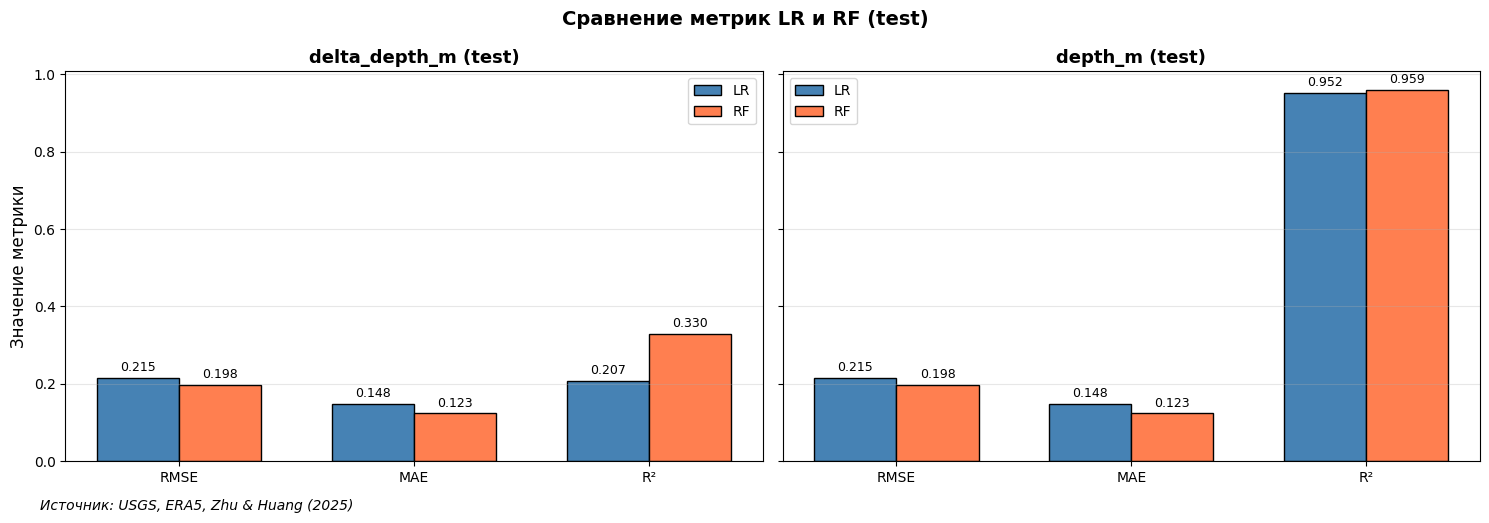

In [121]:
# Визуализируем полученные метрики LR и RF (test)

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

# delta_depth_m test
delta_labels = ['RMSE', 'MAE', 'R²']
delta_lr = [rmse_test_delta_lr, mae_test_delta_lr, r2_test_delta_lr]
delta_rf = [rmse_test_delta_rf, mae_test_delta_rf, r2_test_delta_rf]

# depth_m test
depth_lr = [rmse_test_lr, mae_test_lr, r2_test_lr]
depth_rf = [rmse_test_rf, mae_test_rf, r2_test_rf]

x = np.arange(len(delta_labels))
width = 0.35

# delta_depth_m
ax1 = axes[0]
ax1.bar(x - width/2, delta_lr, width, label='LR', color='steelblue', edgecolor='black')
ax1.bar(x + width/2, delta_rf, width, label='RF', color='coral', edgecolor='black')
for i, (v1, v2) in enumerate(zip(delta_lr, delta_rf)):
    ax1.text(i - width/2, v1 + 0.01, f'{v1:.3f}', ha='center', va='bottom', fontsize=9)
    ax1.text(i + width/2, v2 + 0.01, f'{v2:.3f}', ha='center', va='bottom', fontsize=9)
ax1.set_xticks(x)
ax1.set_xticklabels(delta_labels)
ax1.set_title('delta_depth_m (test)', fontsize=13, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

# depth_m
ax2 = axes[1]
ax2.bar(x - width/2, depth_lr, width, label='LR', color='steelblue', edgecolor='black')
ax2.bar(x + width/2, depth_rf, width, label='RF', color='coral', edgecolor='black')
for i, (v1, v2) in enumerate(zip(depth_lr, depth_rf)):
    ax2.text(i - width/2, v1 + 0.01, f'{v1:.3f}', ha='center', va='bottom', fontsize=9)
    ax2.text(i + width/2, v2 + 0.01, f'{v2:.3f}', ha='center', va='bottom', fontsize=9)
ax2.set_xticks(x)
ax2.set_xticklabels(delta_labels)
ax2.set_title('depth_m (test)', fontsize=13, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

axes[0].set_ylabel('Значение метрики', fontsize=12)
plt.suptitle('Сравнение метрик LR и RF (test)', fontsize=14, fontweight='bold')

fig.text(0.03, -0.02, 'Источник: USGS, ERA5, Zhu & Huang (2025)', ha='left', fontsize=10, style='italic')
plt.tight_layout()
plt.savefig('../visualizations/metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

Более низкие значения метрики R2 модели LR на delta_depth_m и depth_m, чем модели RF, указывает на то что LR слабо улавливает нелинейные зависимости.

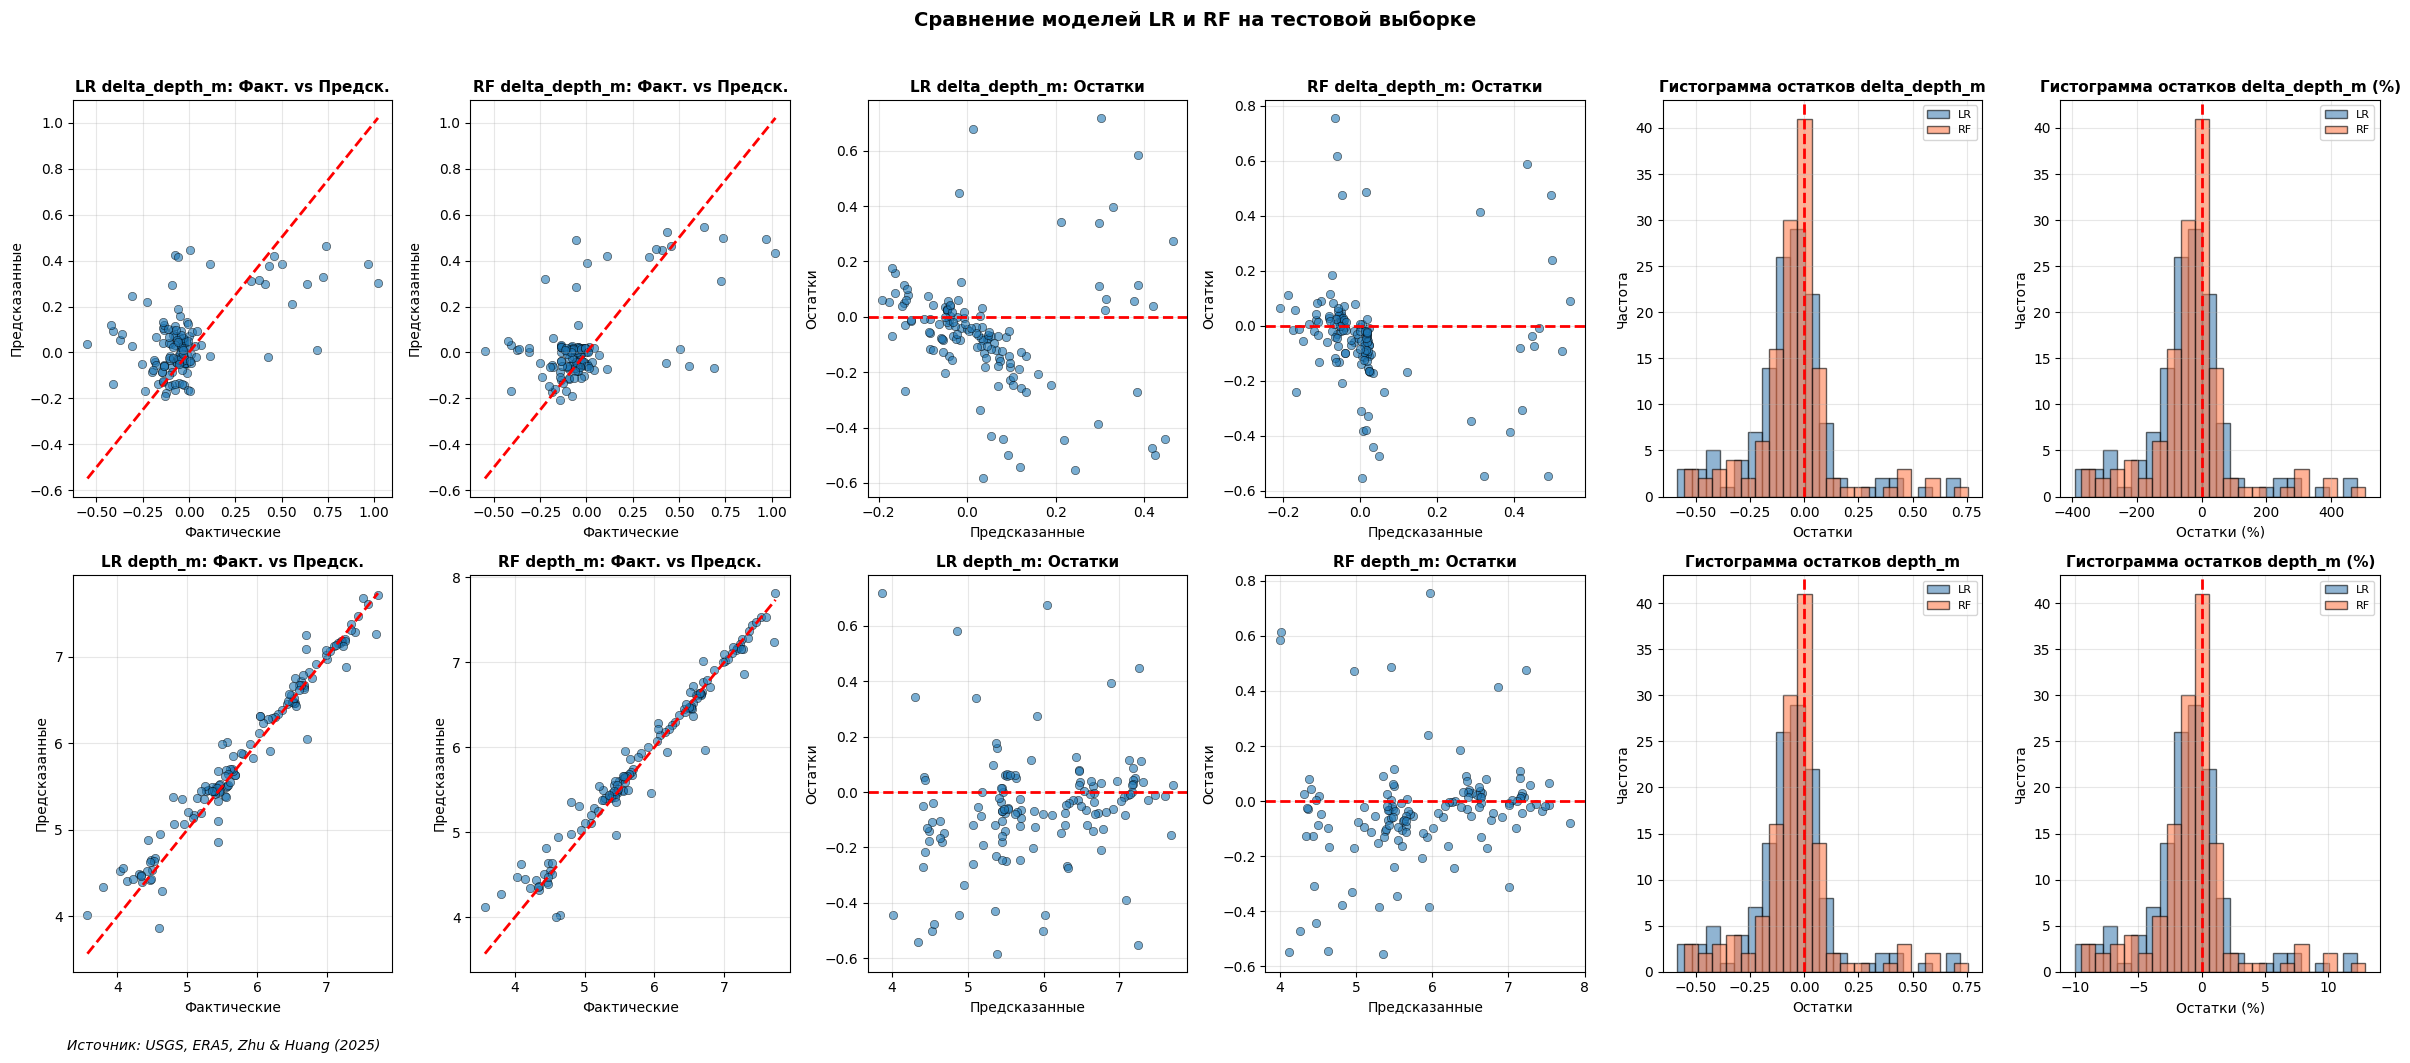

In [122]:
# Визуализируем полученные метрики LR и RF с гистограммами остатков

fig, axes = plt.subplots(2, 6, figsize=(24, 10))

y_test_depth = test_data['depth_m']
y_test_delta = test_data['delta_depth_m']

# delta_depth_m

# 1. LR: Фактические vs Предсказанные delta_depth_m (test)
ax1 = axes[0, 0]
ax1.scatter(y_test_delta, y_pred_test_delta_lr, alpha=0.6, edgecolors='black', linewidth=0.5)
ax1.plot([y_test_delta.min(), y_test_delta.max()], [y_test_delta.min(), y_test_delta.max()], 'r--', linewidth=2)
ax1.set_xlabel('Фактические', fontsize=10)
ax1.set_ylabel('Предсказанные', fontsize=10)
ax1.set_title('LR delta_depth_m: Факт. vs Предск.', fontsize=11, fontweight='bold')
ax1.grid(True, alpha=0.3)

# 2. RF: Фактические vs Предсказанные delta_depth_m (test)
ax2 = axes[0, 1]
ax2.scatter(y_test_delta, y_pred_test_delta_rf, alpha=0.6, edgecolors='black', linewidth=0.5)
ax2.plot([y_test_delta.min(), y_test_delta.max()], [y_test_delta.min(), y_test_delta.max()], 'r--', linewidth=2)
ax2.set_xlabel('Фактические', fontsize=10)
ax2.set_ylabel('Предсказанные', fontsize=10)
ax2.set_title('RF delta_depth_m: Факт. vs Предск.', fontsize=11, fontweight='bold')
ax2.grid(True, alpha=0.3)

# 3. LR: Остатки delta_depth_m (test)
ax3 = axes[0, 2]
residuals_lr = y_test_delta - y_pred_test_delta_lr
ax3.scatter(y_pred_test_delta_lr, residuals_lr, alpha=0.6, edgecolors='black', linewidth=0.5)
ax3.axhline(y=0, color='r', linestyle='--', linewidth=2)
ax3.set_xlabel('Предсказанные', fontsize=10)
ax3.set_ylabel('Остатки', fontsize=10)
ax3.set_title('LR delta_depth_m: Остатки', fontsize=11, fontweight='bold')
ax3.grid(True, alpha=0.3)

# 4. RF: Остатки delta_depth_m (test)
ax4 = axes[0, 3]
residuals_rf = y_test_delta - y_pred_test_delta_rf
ax4.scatter(y_pred_test_delta_rf, residuals_rf, alpha=0.6, edgecolors='black', linewidth=0.5)
ax4.axhline(y=0, color='r', linestyle='--', linewidth=2)
ax4.set_xlabel('Предсказанные', fontsize=10)
ax4.set_ylabel('Остатки', fontsize=10)
ax4.set_title('RF delta_depth_m: Остатки', fontsize=11, fontweight='bold')
ax4.grid(True, alpha=0.3)

# 5. Гистограмма остатков delta_depth_m
ax5 = axes[0, 4]
ax5.hist(residuals_lr, bins=20, alpha=0.6, color='steelblue', edgecolor='black', label='LR')
ax5.hist(residuals_rf, bins=20, alpha=0.6, color='coral', edgecolor='black', label='RF')
ax5.axvline(x=0, color='r', linestyle='--', linewidth=2)
ax5.set_xlabel('Остатки', fontsize=10)
ax5.set_ylabel('Частота', fontsize=10)
ax5.set_title('Гистограмма остатков delta_depth_m', fontsize=11, fontweight='bold')
ax5.legend(fontsize=8)
ax5.grid(True, alpha=0.3)

# 6. Гистограмма остатков в процентах
ax6 = axes[0, 5]
ax5_percent = residuals_lr / y_test_delta.abs().mean() * 100
ax6_percent = residuals_rf / y_test_delta.abs().mean() * 100
ax6.hist(ax5_percent, bins=20, alpha=0.6, color='steelblue', edgecolor='black', label='LR')
ax6.hist(ax6_percent, bins=20, alpha=0.6, color='coral', edgecolor='black', label='RF')
ax6.axvline(x=0, color='r', linestyle='--', linewidth=2)
ax6.set_xlabel('Остатки (%)', fontsize=10)
ax6.set_ylabel('Частота', fontsize=10)
ax6.set_title('Гистограмма остатков delta_depth_m (%)', fontsize=11, fontweight='bold')
ax6.legend(fontsize=8)
ax6.grid(True, alpha=0.3)

# depth_m (восстановленные)

# 7. LR: Фактические vs Предсказанные depth_m (test)
ax7 = axes[1, 0]
ax7.scatter(y_test_depth, y_test_pred_lr, alpha=0.6, edgecolors='black', linewidth=0.5)
ax7.plot([y_test_depth.min(), y_test_depth.max()], [y_test_depth.min(), y_test_depth.max()], 'r--', linewidth=2)
ax7.set_xlabel('Фактические', fontsize=10)
ax7.set_ylabel('Предсказанные', fontsize=10)
ax7.set_title('LR depth_m: Факт. vs Предск.', fontsize=11, fontweight='bold')
ax7.grid(True, alpha=0.3)

# 8. RF: Фактические vs Предсказанные depth_m (test)
ax8 = axes[1, 1]
ax8.scatter(y_test_depth, y_test_pred_rf, alpha=0.6, edgecolors='black', linewidth=0.5)
ax8.plot([y_test_depth.min(), y_test_depth.max()], [y_test_depth.min(), y_test_depth.max()], 'r--', linewidth=2)
ax8.set_xlabel('Фактические', fontsize=10)
ax8.set_ylabel('Предсказанные', fontsize=10)
ax8.set_title('RF depth_m: Факт. vs Предск.', fontsize=11, fontweight='bold')
ax8.grid(True, alpha=0.3)

# 9. LR: Остатки depth_m (test)
ax9 = axes[1, 2]
residuals_lr_m = y_test_depth - y_test_pred_lr
ax9.scatter(y_test_pred_lr, residuals_lr_m, alpha=0.6, edgecolors='black', linewidth=0.5)
ax9.axhline(y=0, color='r', linestyle='--', linewidth=2)
ax9.set_xlabel('Предсказанные', fontsize=10)
ax9.set_ylabel('Остатки', fontsize=10)
ax9.set_title('LR depth_m: Остатки', fontsize=11, fontweight='bold')
ax9.grid(True, alpha=0.3)

# 10. RF: Остатки depth_m (test)
ax10 = axes[1, 3]
residuals_rf_m = y_test_depth - y_test_pred_rf
ax10.scatter(y_test_pred_rf, residuals_rf_m, alpha=0.6, edgecolors='black', linewidth=0.5)
ax10.axhline(y=0, color='r', linestyle='--', linewidth=2)
ax10.set_xlabel('Предсказанные', fontsize=10)
ax10.set_ylabel('Остатки', fontsize=10)
ax10.set_title('RF depth_m: Остатки', fontsize=11, fontweight='bold')
ax10.grid(True, alpha=0.3)

# 11. Гистограмма остатков depth_m
ax11 = axes[1, 4]
ax11.hist(residuals_lr_m, bins=20, alpha=0.6, color='steelblue', edgecolor='black', label='LR')
ax11.hist(residuals_rf_m, bins=20, alpha=0.6, color='coral', edgecolor='black', label='RF')
ax11.axvline(x=0, color='r', linestyle='--', linewidth=2)
ax11.set_xlabel('Остатки', fontsize=10)
ax11.set_ylabel('Частота', fontsize=10)
ax11.set_title('Гистограмма остатков depth_m', fontsize=11, fontweight='bold')
ax11.legend(fontsize=8)
ax11.grid(True, alpha=0.3)

# 12. Гистограмма остатков в процентах
ax12 = axes[1, 5]
ax11_percent = residuals_lr_m / y_test_depth.abs().mean() * 100
ax12_percent = residuals_rf_m / y_test_depth.abs().mean() * 100
ax12.hist(ax11_percent, bins=20, alpha=0.6, color='steelblue', edgecolor='black', label='LR')
ax12.hist(ax12_percent, bins=20, alpha=0.6, color='coral', edgecolor='black', label='RF')
ax12.axvline(x=0, color='r', linestyle='--', linewidth=2)
ax12.set_xlabel('Остатки (%)', fontsize=10)
ax12.set_ylabel('Частота', fontsize=10)
ax12.set_title('Гистограмма остатков depth_m (%)', fontsize=11, fontweight='bold')
ax12.legend(fontsize=8)
ax12.grid(True, alpha=0.3)

plt.suptitle('Сравнение моделей LR и RF на тестовой выборке', fontsize=14, fontweight='bold', y=1.02)
fig.text(0.03, -0.02, 'Источник: USGS, ERA5, Zhu & Huang (2025)', ha='left', fontsize=10, style='italic')
plt.tight_layout()
plt.savefig('../visualizations/lr_rf_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

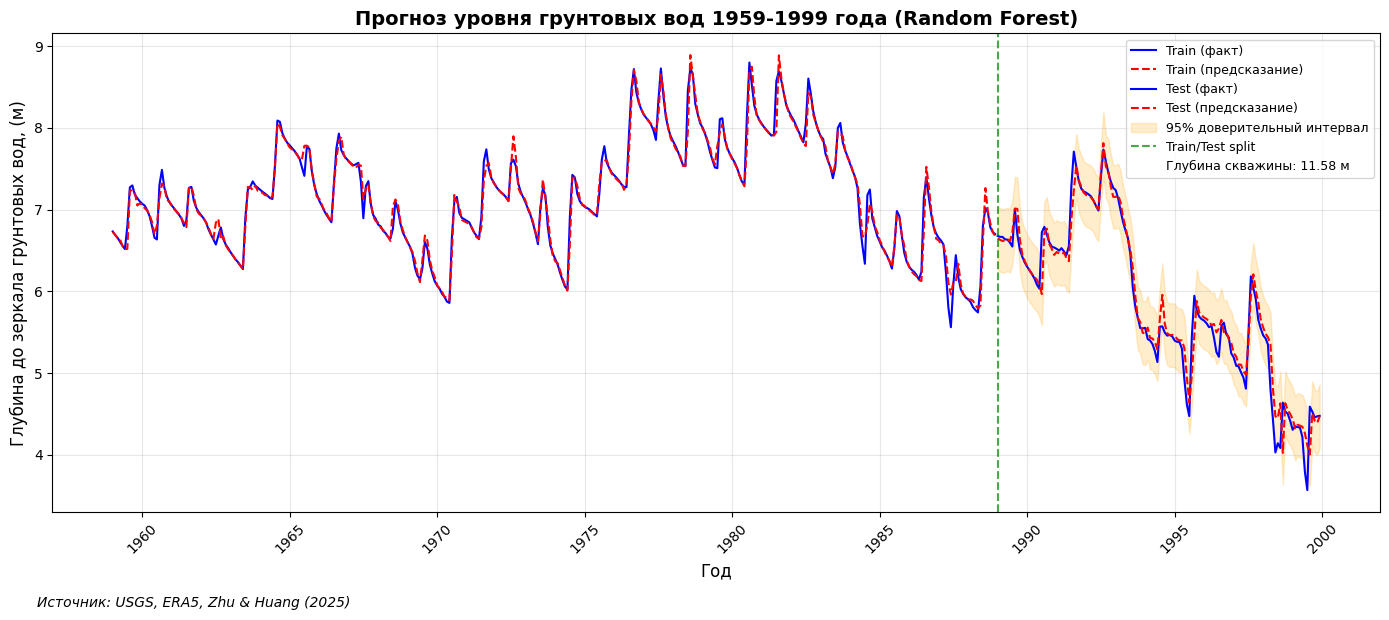

In [123]:
# График: Вся выборка с доверительным интервалом и глубиной скважины

fig, ax = plt.subplots(figsize=(14, 6))

# Обучающая выборка
ax.plot(train_data['month_start'], train_data['depth_m'], 'b-', label='Train (факт)', linewidth=1.5)
ax.plot(train_data['month_start'], y_train_pred_rf, 'r--', label='Train (предсказание)', linewidth=1.5)

# Тестовая выборка
ax.plot(test_data['month_start'], test_data['depth_m'], 'b-', label='Test (факт)', linewidth=1.5)
ax.plot(test_data['month_start'], y_test_pred_rf, 'r--', label='Test (предсказание)', linewidth=1.5)

# Доверительный интервал (примерно ±2 * RMSE)
rmse = rmse_test_rf
ax.fill_between(test_data['month_start'], 
                y_test_pred_rf - 1.96*rmse, 
                y_test_pred_rf + 1.96*rmse, 
                color='orange', alpha=0.2, label='95% доверительный интервал')

# Вертикальная линия раздела train/test
split_date = test_data['month_start'].min()
ax.axvline(x=split_date, color='green', linestyle='--', linewidth=1.5, alpha=0.7, label='Train/Test split')

# Глубина скважины 
ax.plot([], [], ' ', label=f'Глубина скважины: {round(test_data['well_depth_m'].iloc[0],2)} м')

ax.set_xlabel('Год', fontsize=12)
ax.set_ylabel('Глубина до зеркала грунтовых вод, (м)', fontsize=12)
ax.set_title('Прогноз уровня грунтовых вод 1959-1999 года (Random Forest)', fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=9)
ax.grid(True, alpha=0.3)
ax.tick_params(axis='x', rotation=45)

fig.text(0.03, -0.02, 'Источник: USGS, ERA5, Zhu & Huang (2025)', ha='left', fontsize=10, style='italic')
plt.tight_layout()
plt.savefig('../visualizations/rf_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

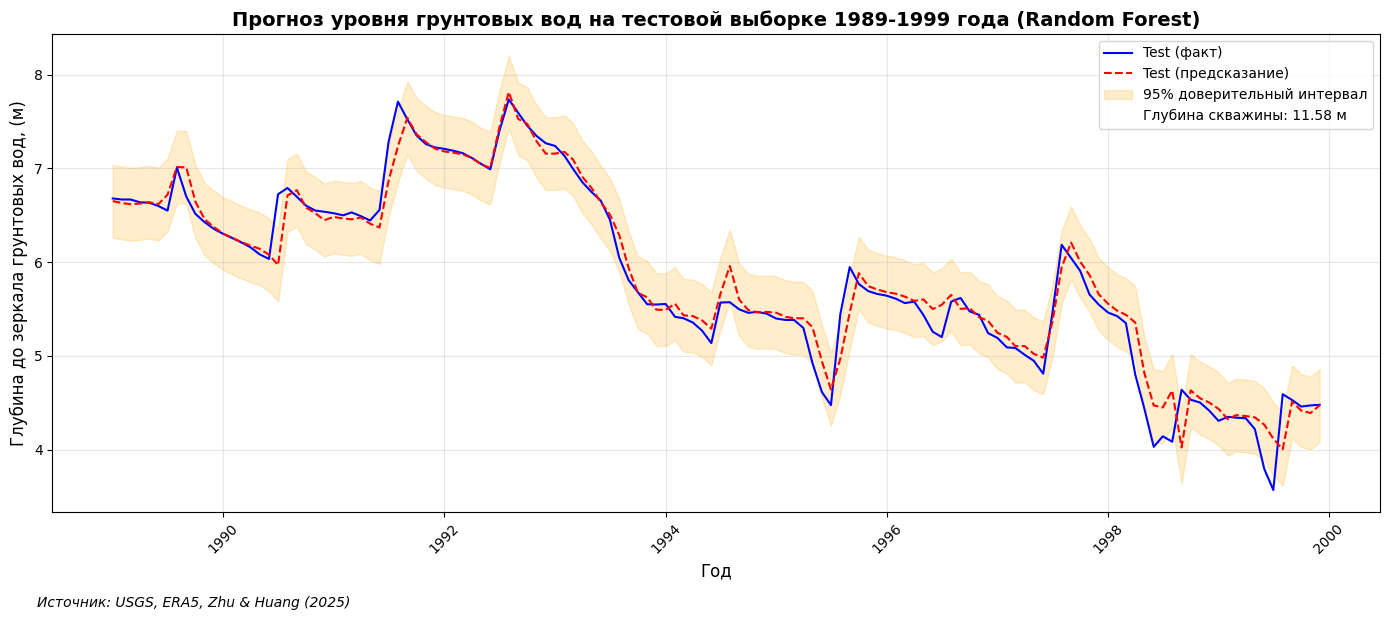

In [124]:
# График: Test выборка с доверительным интервалом и глубиной скважины

fig, ax = plt.subplots(figsize=(14, 6))

# Тестовая выборка - факт
ax.plot(test_data['month_start'], test_data['depth_m'], 'b-', label='Test (факт)', linewidth=1.5)

# Тестовая выборка - предсказание
ax.plot(test_data['month_start'], y_test_pred_rf, 'r--', label='Test (предсказание)', linewidth=1.5)

# Доверительный интервал (±1.96 * RMSE)
rmse = rmse_test_rf
ax.fill_between(test_data['month_start'], 
                y_test_pred_rf - 1.96*rmse, 
                y_test_pred_rf + 1.96*rmse, 
                color='orange', alpha=0.2, label='95% доверительный интервал')


# Глубина скважины - только в легенде
ax.plot([], [], ' ', label=f'Глубина скважины: {round(test_data['well_depth_m'].iloc[0],2)} м')
ax.set_xlabel('Год', fontsize=12)
ax.set_ylabel('Глубина до зеркала грунтовых вод, (м)', fontsize=12)
ax.set_title('Прогноз уровня грунтовых вод на тестовой выборке 1989-1999 года (Random Forest)', fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)
ax.tick_params(axis='x', rotation=45)

fig.text(0.03, -0.02, 'Источник: USGS, ERA5, Zhu & Huang (2025)', ha='left', fontsize=10, style='italic')
plt.tight_layout()
plt.savefig('../visualizations/rf_predictions_test.png', dpi=150, bbox_inches='tight')
plt.show()

# 3. Выводы

В ходе работы была разработана модель машинного обучения для прогнозирования уровня грунтовых вод на основе климатических факторов. Установлено, что наибольшее влияние на динамику уровня оказывают температура воздуха, осадки и глубина промерзания почвы. Модель Random Forest продемонстрировала высокое качество прогнозирования, значительно превосходя базовую линейную модель, что указывает на наличие нелинейных зависимостей в данных. При этом гидрогеологические характеристики скважины не оказали значимого влияния в рамках данной задачи, поскольку являются постоянными во времени. Разработанная модель может быть использована для прогнозирования уровня грунтовых вод в рамках одной скважины, однако для повышения универсальности требуется использование данных по нескольким объектам наблюдений